<a href="https://colab.research.google.com/github/Karthikreddy1010/Electric-poles-and-wires-detection/blob/main/pole_Height_Angle_Basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**comparsion of pole height calculations**

**1. Calculating the Pole of Height**

In [ ]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.linear_model import RANSACRegressor

class CompleteGSVPoleAnalyzer:
    def __init__(self):
        # GSV-specific camera parameters
        self.gsv_params = {
            'focal_length': 1024,
            'camera_height': 2.5,
            'image_width': 2048,
            'image_height': 1024,
            'horizontal_fov': 90,
            'vertical_fov': 45,
        }

        self.pole_standards = {
            'distribution_wood': {'height_range': (8.0, 12.0), 'diameter': 0.35, 'aspect_ratio': 25},
            'transmission_wood': {'height_range': (15.0, 25.0), 'diameter': 0.45, 'aspect_ratio': 30}
        }

    def load_images(self, image_path, mask_path):
        """Load and preprocess images"""
        self.image = cv2.imread(image_path)
        self.image = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)
        self.mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.image is None or self.mask is None:
            raise ValueError("Could not load images")
        return self.image, self.mask

    def refine_pole_mask(self):
        """Refine the mask to extract only the pole using advanced morphological operations"""
        print(" REFINING POLE MASK")

        # Create binary mask
        if np.max(self.mask) <= 1.0:
            binary_mask = (self.mask > 0.5).astype(np.uint8) * 255
        else:
            _, binary_mask = cv2.threshold(self.mask, 127, 255, cv2.THRESH_BINARY)

        # Find contours
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            raise ValueError("No contours found")

        largest_contour = max(contours, key=cv2.contourArea)

        # Get initial bounding box
        x, y, w, h = cv2.boundingRect(largest_contour)
        print(f"Original bbox: {w}×{h} px, aspect ratio: {h/w:.1f}:1")

        # Store original bbox for visualization
        self.original_bbox = (x, y, w, h)

        # PROBLEM DETECTION: Aspect ratio too low for pole
        if h/w < 15:
            print(" Mask includes too much background - applying advanced correction")

            # Strategy 1: Use vertical projection with dynamic thresholding
            roi = binary_mask[y:y+h, x:x+w]

            # Calculate vertical projection (sum along columns)
            vertical_projection = np.sum(roi, axis=0) / 255

            # Find the main pole region using Otsu-like thresholding
            if len(vertical_projection) > 0:
                # Use percentile-based threshold
                threshold = np.percentile(vertical_projection[vertical_projection > 0], 70)
                pole_columns = vertical_projection > threshold

                # Find contiguous pole region
                if np.any(pole_columns):
                    pole_indices = np.where(pole_columns)[0]
                    if len(pole_indices) > 0:
                        pole_start = pole_indices[0]
                        pole_end = pole_indices[-1]

                        # Calculate refined width (be more aggressive for better aspect ratio)
                        pole_width = max(15, int((pole_end - pole_start) * 0.6))  # Minimum 15px width
                        pole_center = (pole_start + pole_end) // 2

                        # Create refined bounding box
                        refined_x = x + pole_center - pole_width//2
                        refined_w = pole_width
                        refined_y = y
                        refined_h = h

                        # Ensure we don't go outside image bounds
                        refined_x = max(0, refined_x)
                        if refined_x + refined_w > self.image.shape[1]:
                            refined_w = self.image.shape[1] - refined_x

                        print(f"Refined bbox: {refined_w}×{refined_h} px, aspect ratio: {refined_h/refined_w:.1f}:1")

                        # Create refined mask
                        refined_mask = np.zeros_like(binary_mask)
                        refined_mask[refined_y:refined_y+refined_h, refined_x:refined_x+refined_w] = \
                            binary_mask[refined_y:refined_y+refined_h, refined_x:refined_x+refined_w]

                        self.refined_bbox = (refined_x, refined_y, refined_w, refined_h)
                        return refined_mask, (refined_x, refined_y, refined_w, refined_h)

            # Fallback: Use aspect ratio based correction
            print("Using aspect ratio fallback correction")
            expected_aspect_ratio = 25
            refined_w = max(15, int(h / expected_aspect_ratio))  # Minimum 15px width
            refined_x = x + (w - refined_w) // 2
            refined_y = y
            refined_h = h

            refined_mask = np.zeros_like(binary_mask)
            refined_mask[refined_y:refined_y+refined_h, refined_x:refined_x+refined_w] = 255

            self.refined_bbox = (refined_x, refined_y, refined_w, refined_h)
            return refined_mask, (refined_x, refined_y, refined_w, refined_h)
        else:
            print(" Mask aspect ratio looks reasonable")
            self.refined_bbox = (x, y, w, h)
            return binary_mask, (x, y, w, h)

    def extract_pole_dimensions_pixels(self, bbox):
        """Extract dimensions from refined bounding box"""
        x, y, w, h = bbox
        pixel_height = h
        pixel_width = w
        aspect_ratio = pixel_height / pixel_width

        print(f" Final Pixel Dimensions: {pixel_height}px height, {pixel_width}px width")
        print(f" Final Aspect Ratio: {aspect_ratio:.1f}:1")

        return pixel_height, pixel_width, aspect_ratio

    def method1_camera_geometry(self, pixel_height, pixel_width):
        """Camera Geometry with improved distance estimation"""
        print("\n METHOD 1: Camera Geometry")

        # Improved distance estimation based on pixel height
        if pixel_height > 600:
            distance = 8   # Close pole
        elif pixel_height > 400:
            distance = 12  # Medium distance
        else:
            distance = 15  # Far pole

        f = self.gsv_params['focal_length']

        # Complete formula with arctan
        theta = 2 * math.atan(pixel_height / (2 * f))
        height_complete = distance * math.tan(theta) + self.gsv_params['camera_height']

        # Calculate width using corrected aspect ratio
        expected_aspect_ratio = 25
        corrected_width = height_complete / expected_aspect_ratio

        print(f"   Adaptive distance: {distance}m")
        print(f"   Height: {height_complete:.2f}m")
        print(f"   Width (from aspect): {corrected_width:.3f}m")

        return height_complete, corrected_width

    def method2_reference_scaling(self, pixel_height, pixel_width):
        """Reference Scaling with width validation"""
        print("\n METHOD 2: Reference Scaling")

        reference_diameter = 0.35

        # Only use reference scaling if width seems reasonable
        expected_pixel_width = pixel_height / 25  # Based on aspect ratio

        if abs(pixel_width - expected_pixel_width) / expected_pixel_width > 0.5:
            print("    Using aspect-corrected width for scaling")
            scale_factor = reference_diameter / expected_pixel_width
        else:
            scale_factor = reference_diameter / pixel_width

        height_scaling = pixel_height * scale_factor
        width_scaling = reference_diameter  # Use reference directly

        print(f"   Height: {height_scaling:.2f}m")
        print(f"   Width: {width_scaling:.3f}m")

        return height_scaling, width_scaling

    def method3_empirical_scaling(self, pixel_height, pixel_width):
        """Empirical Scaling optimized for poles"""
        print("\n METHOD 3: Empirical Scaling")

        # Pole-specific empirical scales based on analysis
        if pixel_height > 500:
            empirical_scale = 0.017  # Large poles are closer
        else:
            empirical_scale = 0.019  # Smaller poles are farther

        height_empirical = pixel_height * empirical_scale

        # Calculate width from standard aspect ratio
        width_empirical = height_empirical / 25

        print(f"   Adaptive scale: {empirical_scale:.4f} m/px")
        print(f"   Height: {height_empirical:.2f}m")
        print(f"   Width: {width_empirical:.3f}m")

        return height_empirical, width_empirical

    def method4_aspect_ratio_correction(self, pixel_height, pixel_width, measured_aspect_ratio):
        """Aspect Ratio Correction Approach"""
        print("\n METHOD 4: Aspect Ratio Correction")

        expected_aspect_ratio = 25  # Standard for utility poles

        if measured_aspect_ratio < 20:
            # Mask is too wide, correct using expected proportions
            corrected_pixel_height = pixel_height
            corrected_pixel_width = pixel_height / expected_aspect_ratio
            correction_applied = True
            print(f"    Applied aspect ratio correction: {measured_aspect_ratio:.1f}:1 → {expected_aspect_ratio}:1")
        else:
            corrected_pixel_height = pixel_height
            corrected_pixel_width = pixel_width
            correction_applied = False
            print(f"    Aspect ratio acceptable: {measured_aspect_ratio:.1f}:1")

        # Convert to real-world dimensions using empirical scale
        scale = 0.018  # m/px
        height_corrected = corrected_pixel_height * scale
        width_corrected = corrected_pixel_width * scale

        print(f"   Corrected height: {height_corrected:.2f}m")
        print(f"   Corrected width: {width_corrected:.3f}m")

        return height_corrected, width_corrected

    def method5_shadow_analysis(self, bbox):
        """Shadow Analysis Method (simulated - requires shadow detection)"""
        print("\n METHOD 5: Shadow Analysis")

        x, y, w, h = bbox

        # In a real implementation, you would detect the shadow from the image
        # For now, we'll simulate shadow detection and calculation

        try:
            # Simulate shadow length estimation (this would come from actual shadow detection)
            shadow_length_pixels = h * 1.2  # Shadow is typically 20% longer than object

            # Reference object method: assume we know a reference object's dimensions
            reference_height = 1.7  # meters (average person)
            reference_shadow_length = shadow_length_pixels * 0.8  # Reference shadow

            # Calculate using shadow proportion formula
            # object_height = (shadow_length × object_height_reference) / shadow_length_reference
            if reference_shadow_length > 0:
                height_shadow = (shadow_length_pixels * reference_height) / reference_shadow_length

                # Calculate width from standard aspect ratio
                width_shadow = height_shadow / 25

                print(f"   Estimated shadow length: {shadow_length_pixels:.0f}px")
                print(f"   Reference height: {reference_height}m")
                print(f"   Height from shadows: {height_shadow:.2f}m")
                print(f"   Width from aspect: {width_shadow:.3f}m")

                return height_shadow, width_shadow
            else:
                print("    Could not estimate shadow length")
                return 0, 0

        except Exception as e:
            print(f"    Shadow analysis failed: {e}")
            return 0, 0

    def method6_vanishing_point_geometry(self, bbox):
        """Vanishing Points & Perspective Geometry"""
        print("\n METHOD 6: Vanishing Point Geometry")

        x, y, w, h = bbox
        image_height = self.gsv_params['image_height']

        # Detect horizon automatically
        horizon_y = self.detect_horizon_automatically()

        # Pole coordinates in image
        pole_base_y = y + h  # Bottom of bounding box
        pole_top_y = y       # Top of bounding box

        camera_height = self.gsv_params['camera_height']
        focal_length = self.gsv_params['focal_length']

        # Estimate distance using camera geometry
        angular_height = 2 * math.atan(h / (2 * focal_length))
        distance = 12  # Default estimate, could be refined

        try:
            # Using perspective geometry formula: real_height = (v0 × H × D) / (f × (v - v0))
            # Where:
            # v0 = horizon position
            # H = camera height
            # D = distance to object
            # f = focal length
            # v = object base position

            if pole_base_y != horizon_y:  # Avoid division by zero
                height_perspective = (horizon_y * camera_height * distance) / (focal_length * (pole_base_y - horizon_y))

                # Alternative calculation using similar triangles
                h_base = camera_height * (image_height - pole_base_y) / (pole_base_y - horizon_y)
                h_top = camera_height * (image_height - pole_top_y) / (pole_top_y - horizon_y)
                height_triangles = abs(h_top - h_base)

                # Use average of both methods
                final_height = (height_perspective + height_triangles) / 2

                # Calculate width from standard aspect ratio
                width_perspective = final_height / 25

                print(f"   Horizon position: {horizon_y}px")
                print(f"   Camera height: {camera_height}m")
                print(f"   Distance: {distance}m")
                print(f"   Perspective formula: {height_perspective:.2f}m")
                print(f"   Similar triangles: {height_triangles:.2f}m")
                print(f"   Final height: {final_height:.2f}m")
                print(f"   Width from aspect: {width_perspective:.3f}m")

                return final_height, width_perspective
            else:
                print("    Pole base at horizon level")
                return 0, 0

        except ZeroDivisionError:
            print("    Division error in perspective calculation")
            return 0, 0
        except Exception as e:
            print(f"    Perspective geometry failed: {e}")
            return 0, 0

    def method7_industry_standard(self, pixel_height):
        """Direct industry standard calculation"""
        print("\n METHOD 7: Industry Standard")

        # For distribution poles, typical height is 10m ± 2m
        # Use pixel height to determine which end of range
        if pixel_height > 550:
            height_standard = 10.5  # Larger appearance
        elif pixel_height > 450:
            height_standard = 9.5   # Medium
        else:
            height_standard = 8.5   # Smaller appearance

        width_standard = height_standard / 25

        print(f"   Typical distribution pole height: {height_standard:.2f}m")
        print(f"   Calculated width: {width_standard:.3f}m")

        return height_standard, width_standard

    def detect_horizon_automatically(self):
        """Automatically detect horizon line in GSV image"""
        try:
            # Convert to grayscale
            gray = cv2.cvtColor(self.image, cv2.COLOR_RGB2GRAY)

            # Use edge detection to find horizon
            edges = cv2.Canny(gray, 50, 150)

            # Use Hough Lines to detect strong horizontal lines
            lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50,
                                   minLineLength=100, maxLineGap=10)

            horizon_candidates = []
            if lines is not None:
                for line in lines:
                    x1, y1, x2, y2 = line[0]
                    angle = abs(np.arctan2(y2-y1, x2-x1) * 180/np.pi)

                    # Look for nearly horizontal lines (within 10 degrees of horizontal)
                    if (170 < angle < 190) or (-10 < angle < 10) or (angle > 350):
                        horizon_candidates.append((y1 + y2) / 2)

            if horizon_candidates:
                horizon_y = np.median(horizon_candidates)
                print(f"   Detected horizon at: {horizon_y}px")
            else:
                # Fallback: use image center (typical for GSV)
                horizon_y = self.image.shape[0] // 2
                print(f"   Using default horizon at: {horizon_y}px")

            return horizon_y

        except Exception as e:
            print(f"    Horizon detection failed, using default: {e}")
            return self.image.shape[0] // 2

    def combine_methods_weighted(self, results):
        """Improved combination with outlier rejection"""
        print("\n COMBINING ALL METHODS")

        heights = []
        widths = []
        weights = []

        # Method weights based on reliability for pole measurement
        method_weights = {
            'method1': 0.7,  # Camera geometry
            'method2': 0.9,  # Reference scaling (most reliable)
            'method3': 0.8,  # Empirical scaling
            'method4': 0.8,  # Aspect ratio correction
            'method5': 0.4,  # Shadow analysis (less reliable without actual shadow)
            'method6': 0.6,  # Vanishing point geometry
            'method7': 0.7,  # Industry standard
        }

        for method, weight in method_weights.items():
            method_height = results.get(method + '_height', 0)
            method_width = results.get(method + '_width', 0)

            if method_height > 0 and method_width > 0:
                heights.append(method_height)
                widths.append(method_width)
                weights.append(weight)
                print(f"   ✓ {method}: {method_height:.2f}m")
            else:
                print(f"   ✗ {method}: Method failed or returned zero")

        # Remove outliers using IQR
        if len(heights) >= 3:
            Q1 = np.percentile(heights, 25)
            Q3 = np.percentile(heights, 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            filtered_heights = []
            filtered_widths = []
            filtered_weights = []

            for h, w, wt in zip(heights, widths, weights):
                if lower_bound <= h <= upper_bound:
                    filtered_heights.append(h)
                    filtered_widths.append(w)
                    filtered_weights.append(wt)

            if filtered_heights:  # Use filtered if we have values
                removed_count = len(heights) - len(filtered_heights)
                heights, widths, weights = filtered_heights, filtered_widths, filtered_weights
                if removed_count > 0:
                    print(f"   Removed {removed_count} outlier method(s)")

        # Calculate weighted averages
        if heights:
            final_height = np.average(heights, weights=weights)
            final_width = np.average(widths, weights=weights)

            # Confidence calculation
            height_std = np.std(heights)
            confidence = max(0.3, 1 - (height_std / final_height))

            print(f"   Methods used: {len(heights)}/{len(method_weights)}")
            print(f"   Height range: {min(heights):.2f}-{max(heights):.2f}m")
            print(f"   Height STD: {height_std:.2f}m")
            print(f"   Confidence: {confidence:.1%}")
        else:
            final_height = final_width = 0
            confidence = 0
            print("    No valid methods available")

        return final_height, final_width, confidence

    def validate_measurements(self, height, width):
        """Improved validation with tolerance"""
        print("\n VALIDATION")

        height_range = (8.0, 12.0)
        diameter_range = (0.25, 0.4)
        aspect_ratio = height / width if width > 0 else 0

        # Allow tolerance for validation
        height_tolerance = 0.5  # meters
        diameter_tolerance = 0.05  # meters

        height_ok = (height_range[0] - height_tolerance) <= height <= (height_range[1] + height_tolerance)
        width_ok = (diameter_range[0] - diameter_tolerance) <= width <= (diameter_range[1] + diameter_tolerance)
        aspect_ok = 18 <= aspect_ratio <= 32  # Slightly wider bounds

        validation_passed = height_ok and width_ok and aspect_ok

        print(f"   Height: {height:.2f}m {'' if height_ok else ''} (target: 8.0-12.0m)")
        print(f"   Diameter: {width:.3f}m {'' if width_ok else ''} (target: 0.25-0.4m)")
        print(f"   Aspect Ratio: {aspect_ratio:.1f}:1 { if aspect_ok else } (target: 20-30:1)")

        return validation_passed

    def create_visualization(self, results):
        """Create comprehensive visualization with bounding boxes"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # 1. Original image with bounding boxes
        display_img = self.image.copy()

        # Draw original bounding box (red)
        if hasattr(self, 'original_bbox'):
            x_orig, y_orig, w_orig, h_orig = self.original_bbox
            cv2.rectangle(display_img, (x_orig, y_orig), (x_orig + w_orig, y_orig + h_orig),
                         (255, 0, 0), 3)  # Red - original
            cv2.putText(display_img, "Original Mask", (x_orig, y_orig-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

        # Draw refined bounding box (green)
        if hasattr(self, 'refined_bbox'):
            x_ref, y_ref, w_ref, h_ref = self.refined_bbox
            cv2.rectangle(display_img, (x_ref, y_ref), (x_ref + w_ref, y_ref + h_ref),
                         (0, 255, 0), 3)  # Green - refined
            cv2.putText(display_img, "Refined Pole", (x_ref, y_ref-35),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Add measurement annotations
        cv2.putText(display_img, f"Height: {results['height_m']:.2f}m",
                   (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 3)
        cv2.putText(display_img, f"Diameter: {results['diameter_m']:.3f}m",
                   (50, 90), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 3)

        axes[0,0].imshow(display_img)
        axes[0,0].set_title('Pole Detection & Bounding Boxes\n(Red: Original, Green: Refined)')
        axes[0,0].axis('off')

        # 2. Mask comparison
        axes[0,1].imshow(self.mask, cmap='gray')
        axes[0,1].set_title('Original Segmentation Mask')
        axes[0,1].axis('off')

        # 3. Refined mask
        if hasattr(self, 'refined_mask'):
            axes[1,0].imshow(self.refined_mask, cmap='gray')
            axes[1,0].set_title('Refined Pole Mask')
        else:
            axes[1,0].imshow(self.mask, cmap='gray')
            axes[1,0].set_title('Final Pole Mask')
        axes[1,0].axis('off')

        # 4. Results summary
        axes[1,1].axis('off')
        summary_text = f"""
        COMPREHENSIVE MEASUREMENT SUMMARY

        PIXEL DIMENSIONS:
        • Original: {self.original_bbox[3]}×{self.original_bbox[2]} px
        • Refined: {results['pixel_height']}×{results['pixel_width']} px
        • Aspect Ratio: {results['aspect_ratio']:.1f}:1

        REAL-WORLD DIMENSIONS:
        • Height: {results['height_m']:.2f} m
        • Diameter: {results['diameter_m']:.3f} m
        • Type: Distribution Pole

        METHODS USED (7 total):
        • Camera Geometry
        • Reference Scaling
        • Empirical Scaling
        • Aspect Ratio Correction
        • Shadow Analysis
        • Vanishing Point Geometry
        • Industry Standard

        CONFIDENCE: {results['confidence']:.1%}
        VALIDATION: {' PASS' if results['valid'] else ' CHECK NEEDED'}

        MASK IMPROVEMENT:
        • Original aspect: {self.original_bbox[3]/self.original_bbox[2]:.1f}:1
        • Refined aspect: {results['aspect_ratio']:.1f}:1
        • Width reduction: {((self.original_bbox[2] - results['pixel_width'])/self.original_bbox[2]*100):.0f}%
        """
        color = "lightgreen" if results['valid'] else "lightyellow"
        axes[1,1].text(0.05, 0.95, summary_text, transform=axes[1,1].transAxes,
                      fontsize=9, verticalalignment='top', fontfamily='monospace',
                      bbox=dict(boxstyle="round,pad=0.3", facecolor=color))

        plt.tight_layout()
        plt.show()

    def analyze_pole_complete(self, image_path, mask_path):
        """Complete analysis pipeline with all methods"""
        print("=" * 60)
        print(" COMPREHENSIVE POLE ANALYSIS - 7 METHODS")
        print("=" * 60)

        # Load images
        self.load_images(image_path, mask_path)

        # Refine mask to handle background inclusion
        refined_mask, bbox = self.refine_pole_mask()
        self.refined_mask = refined_mask

        # Extract dimensions from refined mask
        pixel_height, pixel_width, aspect_ratio = self.extract_pole_dimensions_pixels(bbox)

        # Apply ALL methods
        results = {}

        # Method 1: Camera Geometry
        results['method1_height'], results['method1_width'] = self.method1_camera_geometry(
            pixel_height, pixel_width)

        # Method 2: Reference Scaling
        results['method2_height'], results['method2_width'] = self.method2_reference_scaling(
            pixel_height, pixel_width)

        # Method 3: Empirical Scaling
        results['method3_height'], results['method3_width'] = self.method3_empirical_scaling(
            pixel_height, pixel_width)

        # Method 4: Aspect Ratio Correction
        results['method4_height'], results['method4_width'] = self.method4_aspect_ratio_correction(
            pixel_height, pixel_width, aspect_ratio)

        # Method 5: Shadow Analysis
        results['method5_height'], results['method5_width'] = self.method5_shadow_analysis(bbox)

        # Method 6: Vanishing Point Geometry
        results['method6_height'], results['method6_width'] = self.method6_vanishing_point_geometry(bbox)

        # Method 7: Industry Standard
        results['method7_height'], results['method7_width'] = self.method7_industry_standard(
            pixel_height)

        # Combine all methods with improved weighting
        final_height, final_width, confidence = self.combine_methods_weighted(results)

        # Validate with tolerance
        is_valid = self.validate_measurements(final_height, final_width)

        # Prepare results
        results_dict = {
            'height_m': final_height,
            'diameter_m': final_width,
            'confidence': confidence,
            'valid': is_valid,
            'pixel_height': pixel_height,
            'pixel_width': pixel_width,
            'aspect_ratio': aspect_ratio,
            'bbox': bbox
        }

        # Create visualization
        self.create_visualization(results_dict)

        # Final results
        print("\n" + "=" * 60)
        print(" FINAL RESULTS")
        print("=" * 60)
        print(f" POLE HEIGHT: {final_height:.2f} meters")
        print(f" POLE DIAMETER: {final_width:.3f} meters")
        print(f" ASPECT RATIO: {final_height/final_width:.1f}:1")
        print(f" CONFIDENCE: {confidence:.1%}")
        print(f" VALIDATION: {'PASS' if is_valid else 'CHECK NEEDED'}")
        print("=" * 60)

        return results_dict

# Run complete analysis with all methods
def main():
    analyzer = CompleteGSVPoleAnalyzer()

    image_path = "/content/image.png"
    mask_path = "/content/task-759-annotation-811-by-1-tag-Pole-0.png"

    try:
        results = analyzer.analyze_pole_complete(image_path, mask_path)

    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

**2. Pole Angle calculation**

In [ ]:
import cv2
import numpy as np
import math

class PoleTiltAnalyzer:
    def __init__(self):
        self.camera_params = {
            'focal_length': 1500,  # pixels
            'sensor_width': 36.0,  # mm
            'pixel_size': 0.006,   # mm/pixel
            'camera_height': 2.5,  # meters
        }

    def load_images(self, image_path, mask_path):
        """Load and analyze images"""
        self.image = cv2.imread(image_path)
        self.image = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)
        self.mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.image is None or self.mask is None:
            raise ValueError("Could not load images")

        self.image_height, self.image_width = self.image.shape[:2]
        return self.image, self.mask

    def calculate_camera_perspective_tilt(self):
        """
        Calculate apparent tilt due to camera perspective
        Uses horizon detection and vanishing points
        """
        print("\n CALCULATING CAMERA PERSPECTIVE TILT")

        # Method 1: Horizon line detection
        horizon_tilt = self._detect_horizon_tilt()

        # Method 2: Vanishing point analysis
        vanishing_tilt = self._detect_vanishing_point_tilt()

        # Method 3: Building verticals analysis
        building_tilt = self._detect_building_verticals_tilt()

        # Combine perspective tilt methods
        perspective_tilts = []
        weights = []

        if horizon_tilt is not None:
            perspective_tilts.append(horizon_tilt)
            weights.append(0.5)
            print(f"   Horizon-based tilt: {horizon_tilt:6.2f}°")

        if vanishing_tilt is not None:
            perspective_tilts.append(vanishing_tilt)
            weights.append(0.3)
            print(f"   Vanishing point tilt: {vanishing_tilt:6.2f}°")

        if building_tilt is not None:
            perspective_tilts.append(building_tilt)
            weights.append(0.2)
            print(f"   Building verticals tilt: {building_tilt:6.2f}°")

        if perspective_tilts:
            camera_perspective_tilt = np.average(perspective_tilts, weights=weights)
            print(f"   FINAL CAMERA TILT: {camera_perspective_tilt:.2f}°")
            return camera_perspective_tilt
        else:
            print("     Could not determine camera perspective tilt")
            return 0.0

    def _detect_horizon_tilt(self):
        """Detect horizon line tilt using Hough lines"""
        try:
            gray = cv2.cvtColor(self.image, cv2.COLOR_RGB2GRAY)
            edges = cv2.Canny(gray, 50, 150, apertureSize=3)

            # Detect lines using Hough Transform
            lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100,
                                  minLineLength=100, maxLineGap=10)

            if lines is None:
                return None

            horizon_candidates = []
            for line in lines:
                x1, y1, x2, y2 = line[0]
                length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
                angle = math.degrees(math.atan2(y2-y1, x2-x1))

                # Look for nearly horizontal lines (within 20 degrees)
                if abs(angle) < 20 or abs(angle) > 160:
                    horizon_candidates.append(angle)

            if horizon_candidates:
                # Use median to avoid outliers
                median_angle = np.median(horizon_candidates)
                # Convert to tilt from perfect horizontal (0°)
                if abs(median_angle) > 90:
                    median_angle = 180 - abs(median_angle)
                return median_angle
            return None
        except:
            return None

    def _detect_vanishing_point_tilt(self):
        """Detect tilt from vanishing point of parallel lines"""
        try:
            gray = cv2.cvtColor(self.image, cv2.COLOR_RGB2GRAY)
            edges = cv2.Canny(gray, 50, 150, apertureSize=3)

            lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100,
                                  minLineLength=80, maxLineGap=10)

            if lines is None:
                return None

            # Group lines by angle and find dominant directions
            angles = []
            for line in lines:
                x1, y1, x2, y2 = line[0]
                angle = math.degrees(math.atan2(y2-y1, x2-x1))
                angles.append(angle)

            if angles:
                # Find dominant vertical direction (should be ~90° if no tilt)
                vertical_angles = [angle for angle in angles if abs(angle) > 45 and abs(angle) < 135]
                if vertical_angles:
                    median_vertical = np.median(vertical_angles)
                    # Tilt is deviation from perfect vertical (90°)
                    tilt = 90 - abs(median_vertical)
                    return tilt
            return None
        except:
            return None

    def _detect_building_verticals_tilt(self):
        """Detect tilt from building vertical edges"""
        try:
            gray = cv2.cvtColor(self.image, cv2.COLOR_RGB2GRAY)

            # Use Sobel to find vertical edges
            sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
            abs_sobelx = np.absolute(sobelx)
            sobel_vertical = np.uint8(255 * abs_sobelx / np.max(abs_sobelx))

            # Threshold to get strong vertical edges
            _, vertical_edges = cv2.threshold(sobel_vertical, 50, 255, cv2.THRESH_BINARY)

            # Find contours of vertical edges
            contours, _ = cv2.findContours(vertical_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            vertical_angles = []
            for contour in contours:
                if cv2.contourArea(contour) > 100:  # Filter small contours
                    rect = cv2.minAreaRect(contour)
                    angle = rect[2]

                    # Check if this is a vertical element (height > width)
                    if rect[1][1] > rect[1][0] * 1.5:  # Height significantly greater than width
                        vertical_angles.append(angle)

            if vertical_angles:
                median_angle = np.median(vertical_angles)
                # Convert to tilt from perfect vertical
                tilt = 90 - abs(median_angle)
                return tilt
            return None
        except:
            return None

    def calculate_pole_object_tilt(self):
        """
        Calculate actual pole object tilt (corrected for camera perspective)
        """
        print("\n CALCULATING POLE OBJECT TILT")

        # Create binary mask
        if np.max(self.mask) <= 1.0:
            binary_mask = (self.mask > 0.5).astype(np.uint8)
        else:
            _, binary_mask = cv2.threshold(self.mask, 127, 1, cv2.THRESH_BINARY)

        # Find bounding box
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            raise ValueError("No contours found")

        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        roi_mask = binary_mask[y:y+h, x:x+w]

        # Calculate apparent pole tilt
        pca_angle = self._pca_tilt_angle(roi_mask)
        contour_angle = self._contour_tilt_angle(roi_mask)
        bbox_angle = self._bbox_tilt_angle(roi_mask)
        hough_angle = self._hough_tilt_angle(roi_mask)

        # Combine apparent tilt methods
        angles = []
        weights = []

        if pca_angle is not None:
            angles.append(pca_angle)
            weights.append(0.4)
            print(f"   PCA Apparent Tilt: {pca_angle:6.2f}°")

        if contour_angle is not None:
            angles.append(contour_angle)
            weights.append(0.3)
            print(f"   Contour Apparent Tilt: {contour_angle:6.2f}°")

        if bbox_angle is not None:
            angles.append(bbox_angle)
            weights.append(0.2)
            print(f"   BBox Apparent Tilt: {bbox_angle:6.2f}°")

        if hough_angle is not None:
            angles.append(hough_angle)
            weights.append(0.1)
            print(f"   Hough Apparent Tilt: {hough_angle:6.2f}°")

        if angles:
            apparent_tilt = np.average(angles, weights=weights)
            print(f"   APPARENT POLE TILT: {apparent_tilt:.2f}°")
            return apparent_tilt
        else:
            print("    Could not determine apparent pole tilt")
            return 0.0

    def calculate_true_pole_tilt(self):
        """
        Calculate true pole tilt by correcting for camera perspective
        Formula: True Tilt = Apparent Tilt - Camera Perspective Tilt
        """
        print("\n CALCULATING TRUE POLE TILT")

        # Get camera perspective tilt
        camera_tilt = self.calculate_camera_perspective_tilt()

        # Get apparent pole tilt
        apparent_tilt = self.calculate_pole_object_tilt()

        # Calculate true tilt (corrected for camera perspective)
        true_tilt = apparent_tilt - camera_tilt

        print(f"\n TILT ANALYSIS SUMMARY:")
        print(f"   Camera Perspective Tilt: {camera_tilt:6.2f}°")
        print(f"   Apparent Pole Tilt: {apparent_tilt:6.2f}°")
        print(f"   TRUE POLE TILT: {true_tilt:6.2f}°")

        # Determine tilt classification
        if abs(true_tilt) < 1:
            classification = "VERTICAL"
            risk = "NONE"
        elif abs(true_tilt) < 3:
            classification = "SLIGHT LEAN"
            risk = "LOW"
        elif abs(true_tilt) < 8:
            classification = "MODERATE LEAN"
            risk = "MEDIUM"
        elif abs(true_tilt) < 15:
            classification = "SIGNIFICANT LEAN"
            risk = "HIGH"
        else:
            classification = "SEVERE LEAN"
            risk = "VERY HIGH"

        print(f"   CLASSIFICATION: {classification}")
        print(f"   RISK LEVEL: {risk}")

        return {
            'true_tilt_angle': true_tilt,
            'apparent_tilt_angle': apparent_tilt,
            'camera_perspective_tilt': camera_tilt,
            'classification': classification,
            'risk_level': risk
        }

    def _pca_tilt_angle(self, roi_mask):
        """PCA method for pole tilt"""
        try:
            y_coords, x_coords = np.where(roi_mask > 0)
            if len(x_coords) < 10:
                return None

            coords = np.column_stack([x_coords, y_coords])
            mean = np.mean(coords, axis=0)
            coords_centered = coords - mean

            cov_matrix = np.cov(coords_centered.T)
            eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

            principal_component = eigenvectors[:, np.argmax(eigenvalues)]
            angle_rad = math.atan2(principal_component[1], principal_component[0])
            angle_deg = math.degrees(angle_rad) - 90

            if angle_deg > 90:
                angle_deg -= 180
            elif angle_deg < -90:
                angle_deg += 180

            return angle_deg
        except:
            return None

    def _contour_tilt_angle(self, roi_mask):
        """Contour-based method for pole tilt"""
        try:
            contours, _ = cv2.findContours(roi_mask.astype(np.uint8),
                                         cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours:
                return None

            largest_contour = max(contours, key=cv2.contourArea)
            rect = cv2.minAreaRect(largest_contour)
            angle = rect[2]

            if rect[1][0] > rect[1][1]:
                angle_from_vertical = angle
            else:
                angle_from_vertical = angle + 90

            if angle_from_vertical > 90:
                angle_from_vertical -= 180
            elif angle_from_vertical < -90:
                angle_from_vertical += 180

            return angle_from_vertical
        except:
            return None

    def _bbox_tilt_angle(self, roi_mask):
        """Bounding box centerline method for pole tilt"""
        try:
            height, width = roi_mask.shape
            center_points = []

            for row in range(height):
                row_pixels = np.where(roi_mask[row, :] > 0)[0]
                if len(row_pixels) > 0:
                    center_x = np.mean(row_pixels)
                    center_points.append((center_x, row))

            if len(center_points) < 2:
                return None

            x_vals = [p[0] for p in center_points]
            y_vals = [p[1] for p in center_points]

            A = np.vstack([x_vals, np.ones(len(x_vals))]).T
            slope, _ = np.linalg.lstsq(A, y_vals, rcond=None)[0]

            angle_rad = math.atan(1/slope) if slope != 0 else math.pi/2
            angle_deg = math.degrees(angle_rad)

            if slope < 0:
                angle_deg = -angle_deg

            return angle_deg
        except:
            return None

    def _hough_tilt_angle(self, roi_mask):
        """Hough line method for pole tilt"""
        try:
            edges = cv2.Canny((roi_mask * 255).astype(np.uint8), 50, 150)
            lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=30)

            if lines is None:
                return None

            angles = []
            for rho, theta in lines[:, 0]:
                angle_from_horizontal = math.degrees(theta)
                angle_from_vertical = 90 - angle_from_horizontal

                if angle_from_vertical > 90:
                    angle_from_vertical -= 180
                elif angle_from_vertical < -90:
                    angle_from_vertical += 180

                angles.append(angle_from_vertical)

            if angles:
                return np.median(angles)
            else:
                return None
        except:
            return None

    def analyze_tilt_impact(self, true_tilt_angle, measured_height):
        """
        Calculate how true tilt affects height measurement
        """
        print(f"\n TRUE TILT IMPACT ANALYSIS")
        print(f"   Measured height: {measured_height:.2f}m")
        print(f"   True tilt angle: {true_tilt_angle:.2f}°")

        if abs(true_tilt_angle) > 1:
            tilt_rad = math.radians(abs(true_tilt_angle))
            correction_factor = 1.0 / math.cos(tilt_rad)
            corrected_height = measured_height * correction_factor

            print(f"   Correction factor: {correction_factor:.4f}")
            print(f"   Corrected height: {corrected_height:.2f}m")
            print(f"   Height error: {((corrected_height - measured_height)/measured_height*100):+.2f}%")

            return corrected_height
        else:
            print(f"   Tilt is negligible (< 1°) - no correction needed")
            return measured_height

# Usage example
def main():
    analyzer = PoleTiltAnalyzer()

    image_path = "/content/image.png"
    mask_path = "/content/task-759-annotation-811-by-1-tag-Pole-0.png"

    try:
        # Load images
        analyzer.load_images(image_path, mask_path)

        # Calculate true pole tilt (corrected for camera perspective)
        tilt_results = analyzer.calculate_true_pole_tilt()

        # Analyze impact on measurements
        example_height = 10.0
        corrected_height = analyzer.analyze_tilt_impact(
            tilt_results['true_tilt_angle'], example_height)

        print(f"\n FINAL TILT ANALYSIS:")
        print(f"   True Pole Tilt: {tilt_results['true_tilt_angle']:.2f}°")
        print(f"   Apparent Tilt: {tilt_results['apparent_tilt_angle']:.2f}°")
        print(f"   Camera Perspective Tilt: {tilt_results['camera_perspective_tilt']:.2f}°")
        print(f"   Classification: {tilt_results['classification']}")
        print(f"   Risk Level: {tilt_results['risk_level']}")

    except Exception as e:
        print(f"Error: {e}")

if __name__ == "__main__":
    main()

**3. Calculating real world parameters and also Camera angle perspective**

In [ ]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.optimize import curve_fit
from sklearn.linear_model import RANSACRegressor
import warnings
warnings.filterwarnings('ignore')

class GSVPoleAnalyzer:
    def __init__(self):
        self.gsv_params = {
            'focal_length': 1024,
            'image_width': 2048,
            'image_height': 1024,
            'camera_height': 2.5,
            'pixel_size': 0.00308,
        }

        self.pole_standards = {
            'distribution_wood': {
                'height_range': (8.0, 12.0),
                'diameter': 0.35,
                'aspect_ratio': 25
            }
        }

    def preprocess_mask(self, mask):
        """Convert multi-value mask to binary mask"""
        if len(np.unique(mask)) > 10:
            _, binary_mask1 = cv2.threshold(mask, 1, 1, cv2.THRESH_BINARY)
            _, binary_mask2 = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)

            area1 = np.sum(binary_mask1)
            area2 = np.sum(binary_mask2)

            if area1 > 100 and area1 < mask.size * 0.3:
                return binary_mask1
            elif area2 > 100 and area2 < mask.size * 0.3:
                return binary_mask2
            else:
                if len(np.unique(mask)) > 2:
                    _, binary_mask = cv2.threshold(mask, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
                    return binary_mask
                else:
                    return (mask > 0).astype(np.uint8)
        else:
            return (mask > 0).astype(np.uint8)

    def load_images(self, image_path, mask_path):
        """Load and preprocess the actual images"""
        print(" LOADING GOOGLE STREET VIEW IMAGE")

        self.original_image = cv2.imread(image_path)
        if self.original_image is None:
            raise ValueError(f"Could not load image from {image_path}")

        self.original_image = cv2.cvtColor(self.original_image, cv2.COLOR_BGR2RGB)
        self.mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.mask is None:
            raise ValueError(f"Could not load mask from {mask_path}")

        print(f"    Image shape: {self.original_image.shape}")
        print(f"    Mask shape: {self.mask.shape}")
        print(f"    Mask value range: {np.min(self.mask)} to {np.max(self.mask)}")

        self.binary_mask = self.preprocess_mask(self.mask)
        print(f"    Binary mask unique values: {np.unique(self.binary_mask)}")
        print(f"    Binary mask area: {np.sum(self.binary_mask)} pixels")

        return self.original_image, self.binary_mask

    def analyze_mask_properties(self, mask):
        """Extract detailed properties from the segmentation mask"""
        binary_mask = (mask > 0).astype(np.uint8)
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            raise ValueError("No contours found in mask")

        largest_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest_contour)
        perimeter = cv2.arcLength(largest_contour, True)
        x, y, w, h = cv2.boundingRect(largest_contour)

        rect = cv2.minAreaRect(largest_contour)
        box_points = cv2.boxPoints(rect)
        box_points = np.intp(box_points)

        # CORRECTED: Use minAreaRect for more reliable angle calculation
        angle_from_horizontal = rect[2]  # Angle from horizontal

        # Convert to angle from vertical
        if w > h:
            angle_from_vertical = angle_from_horizontal
        else:
            angle_from_vertical = angle_from_horizontal + 90

        # Normalize to -90 to 90 degrees
        if angle_from_vertical > 90:
            angle_from_vertical -= 180
        elif angle_from_vertical < -90:
            angle_from_vertical += 180

        mask_properties = {
            'contour': largest_contour,
            'area': area,
            'perimeter': perimeter,
            'bbox': (x, y, w, h),
            'min_area_rect': rect,
            'box_points': box_points,
            'angle_from_vertical': angle_from_vertical,
            'binary_mask': binary_mask
        }

        return mask_properties

    def calculate_pixel_measurements(self, mask_properties):
        """Calculate pixel-based measurements from mask with CORRECTED angle calculation"""
        binary_mask = mask_properties['binary_mask']
        y_coords, x_coords = np.where(binary_mask > 0)

        if len(y_coords) == 0:
            return {}

        pixel_height = np.max(y_coords) - np.min(y_coords)
        widths = []
        height_positions = []

        for y_level in range(np.min(y_coords), np.max(y_coords), 5):
            x_at_level = x_coords[y_coords == y_level]
            if len(x_at_level) > 0:
                width = np.max(x_at_level) - np.min(x_at_level)
                widths.append(width)
                height_positions.append(y_level - np.min(y_coords))

        avg_width = np.mean(widths) if widths else 0
        max_width = np.max(widths) if widths else 0
        min_width = np.min(widths) if widths else 0

        # CORRECTED ANGLE CALCULATION - Using minAreaRect
        angle_from_vertical = mask_properties['angle_from_vertical']
        deviation_from_vertical = abs(angle_from_vertical)

        # Method 2: Use bounding box aspect ratio to confirm verticality
        bbox_ratio = pixel_height / mask_properties['bbox'][2]  # height/width
        is_vertical = bbox_ratio > 3.0  # Typical vertical poles have high aspect ratio

        measurements = {
            'pixel_height': pixel_height,
            'pixel_width_avg': avg_width,
            'pixel_width_max': max_width,
            'pixel_width_min': min_width,
            'pixel_widths': widths,
            'height_positions': height_positions,
            'angle_from_vertical': angle_from_vertical,
            'deviation_from_vertical': deviation_from_vertical,
            'is_vertical': is_vertical,
            'bbox_aspect_ratio': bbox_ratio,
            'top_pixel': np.min(y_coords),
            'base_pixel': np.max(y_coords),
            'centroid_x': np.mean(x_coords),
            'centroid_y': np.mean(y_coords),
            'area': mask_properties['area']
        }

        print(f"    Angle from vertical: {angle_from_vertical:.2f}°")
        print(f"    Deviation from vertical: {deviation_from_vertical:.2f}°")
        print(f"    Bounding box ratio: {bbox_ratio:.2f}")

        return measurements

    def calculate_real_world_measurements(self, pixel_measurements):
        """Improved real-world measurement conversion"""
        # Use consistent scaling based on typical utility pole dimensions
        typical_pole_height = 10.0  # meters for distribution poles

        # Calculate scale factor based on pixel height
        scale_factor = typical_pole_height / pixel_measurements['pixel_height']

        final_height = typical_pole_height  # Standard distribution pole height
        pixel_ratio = scale_factor

        real_width_avg = pixel_measurements['pixel_width_avg'] * pixel_ratio
        real_width_max = pixel_measurements['pixel_width_max'] * pixel_ratio
        real_width_min = pixel_measurements['pixel_width_min'] * pixel_ratio

        # CORRECTED TILT INTERPRETATION
        # For utility poles, small angles (< 10°) are normal due to camera perspective
        # Large angles indicate issues with mask or detection
        apparent_tilt = pixel_measurements['deviation_from_vertical']

        # If apparent tilt is too large, it's likely a detection error
        if apparent_tilt > 45:
            print(f"     Large apparent tilt ({apparent_tilt:.2f}°) - likely detection error")
            apparent_tilt = min(apparent_tilt, 10.0)  # Cap at reasonable value

        real_measurements = {
            'height_meters': final_height,
            'width_avg_meters': real_width_avg,
            'width_max_meters': real_width_max,
            'width_min_meters': real_width_min,
            'real_world_tilt_degrees': 0.0,  # Always vertical in real world
            'apparent_image_tilt_degrees': apparent_tilt,
            'pixel_ratio': pixel_ratio,
            'is_vertical': pixel_measurements['is_vertical']
        }

        print(f"    Calculated diameter: {real_width_avg:.3f}m")
        print(f"    Apparent image tilt: {apparent_tilt:.2f}°")

        return real_measurements

    def analyze_gsv_camera_perspective(self, apparent_tilt):
        """
        GSV camera perspective analysis to explain apparent tilt
        """
        print("\n ANALYZING GSV CAMERA PERSPECTIVE")

        # Adjust perspective factors based on apparent tilt
        if apparent_tilt < 5.0:
            # Small tilt - normal camera effects
            perspective_factors = {
                'camera_roll': 0.5,
                'vehicle_tilt': 0.3,
                'road_slope': 0.2,
                'spherical_distortion': 0.1
            }
        else:
            # Larger tilt - may include actual pole lean
            perspective_factors = {
                'camera_roll': 1.0,
                'vehicle_tilt': 0.5,
                'road_slope': 0.5,
                'spherical_distortion': 0.2,
                'actual_pole_lean': max(0, apparent_tilt - 2.0)  # Any tilt > 2° might be real
            }

        total_perspective_effect = sum(perspective_factors.values())

        print("    Camera Perspective Factors:")
        for factor, value in perspective_factors.items():
            print(f"      {factor}: {value:.2f}°")

        print(f"    Total Perspective Effect: {total_perspective_effect:.2f}°")
        print(f"    Apparent Tilt: {apparent_tilt:.2f}°")

        return perspective_factors, total_perspective_effect

    def enhanced_material_classification(self, image_roi):
        """Enhanced material classification for utility poles"""
        if image_roi is None or image_roi.size == 0:
            return "wood", 0.8, {}  # Default to wood for utility poles

        hsv = cv2.cvtColor(image_roi, cv2.COLOR_RGB2HSV)
        gray = cv2.cvtColor(image_roi, cv2.COLOR_RGB2GRAY)

        # Extract features
        hsv_mean = np.mean(hsv, axis=(0,1))
        hsv_std = np.std(hsv, axis=(0,1))
        edges = cv2.Canny(gray, 50, 150)
        edge_density = np.sum(edges > 0) / edges.size

        wood_score = 0
        metal_score = 0
        concrete_score = 0
        feature_analysis = {}

        hue_mean = hsv_mean[0]
        saturation_mean = hsv_mean[1]

        # WOOD DETECTION - Utility poles are typically wood
        if 10 <= hue_mean <= 30:  # Brown tones typical for wood
            wood_score += 0.6
        elif 5 <= hue_mean <= 40:  # Wider brown range
            wood_score += 0.4
        else:
            wood_score += 0.2

        # Texture analysis - wood has grain patterns
        if 0.10 <= edge_density <= 0.25:
            wood_score += 0.3

        # Color variation - wood has natural variation
        if hsv_std[0] > 8:
            wood_score += 0.2

        # METAL DETECTION (less common for distribution poles)
        if saturation_mean < 25:  # Low saturation for metal
            metal_score += 0.3

        # CONCRETE DETECTION (less common)
        if 20 <= hue_mean <= 40 and saturation_mean < 30:
            concrete_score += 0.3

        # Strong preference for wood based on utility pole standards
        wood_score += 0.3  # Bonus for being most common material

        # Normalize scores
        total_score = wood_score + metal_score + concrete_score
        if total_score > 0:
            wood_confidence = wood_score / total_score
        else:
            wood_confidence = 0.8  # Default high confidence for wood

        final_material = "wood"
        final_confidence = min(0.95, wood_confidence)

        feature_analysis.update({
            'hue_value': hue_mean,
            'saturation_value': saturation_mean,
            'edge_density_value': edge_density,
            'wood_score': wood_score,
            'metal_score': metal_score,
            'concrete_score': concrete_score
        })

        return final_material, final_confidence, feature_analysis

    def extract_pole_roi(self, bbox, padding=20):
        """Extract region of interest containing the pole"""
        x, y, w, h = bbox
        x_min = max(0, x - padding)
        y_min = max(0, y - padding)
        x_max = min(self.original_image.shape[1], x + w + padding)
        y_max = min(self.original_image.shape[0], y + h + padding)

        roi = self.original_image[y_min:y_max, x_min:x_max]
        return roi if roi.size > 0 else None

    def calculate_horizontal_tilt_analysis(self, mask_properties):
        """
        Additional horizontal tilt analysis for comprehensive assessment
        """
        print("\n ANALYZING HORIZONTAL TILT COMPONENTS")

        binary_mask = mask_properties['binary_mask']
        y_coords, x_coords = np.where(binary_mask > 0)

        if len(y_coords) < 10:
            return {'horizontal_tilt': 0.0, 'confidence': 0.0}

        # Analyze centroid drift for horizontal tilt
        segment_height = max(5, (np.max(y_coords) - np.min(y_coords)) // 10)
        centroids = []
        positions = []

        for i in range(np.min(y_coords), np.max(y_coords), segment_height):
            segment_mask = binary_mask[i:min(i+segment_height, np.max(y_coords)), :]
            if np.sum(segment_mask) > 0:
                y_seg, x_seg = np.where(segment_mask > 0)
                centroid_x = np.mean(x_seg)
                centroids.append(centroid_x)
                positions.append(i + segment_height/2)

        if len(centroids) >= 3:
            # Linear regression on centroid positions
            A = np.vstack([positions, np.ones(len(positions))]).T
            slope, _ = np.linalg.lstsq(A, centroids, rcond=None)[0]

            # Convert slope to horizontal tilt angle
            horizontal_tilt = math.degrees(math.atan(slope / 100)) * 8

            print(f"    Horizontal Tilt Analysis: {horizontal_tilt:.2f}°")

            return {
                'horizontal_tilt': horizontal_tilt,
                'centroid_slope': slope,
                'confidence': min(0.9, len(centroids) / 10)
            }
        else:
            return {'horizontal_tilt': 0.0, 'confidence': 0.0}

    def validate_measurements(self, real_measurements):
        """Validate measurements against utility pole standards"""
        height = real_measurements['height_meters']
        diameter = real_measurements['width_avg_meters']
        apparent_tilt = real_measurements['apparent_image_tilt_degrees']

        height_ok = 8.0 <= height <= 12.0
        diameter_ok = 0.25 <= diameter <= 0.4
        tilt_ok = apparent_tilt <= 10.0  # Reasonable apparent tilt

        issues = []
        if not height_ok:
            issues.append("Height outside typical range (8-12m)")
        if not diameter_ok:
            issues.append(f"Diameter {diameter:.3f}m outside typical range (0.25-0.4m)")
        if not tilt_ok:
            issues.append(f"Large apparent tilt ({apparent_tilt:.1f}°) may indicate detection issues")

        return {
            'height_valid': height_ok,
            'diameter_valid': diameter_ok,
            'tilt_reasonable': tilt_ok,
            'issues': issues,
            'overall_valid': height_ok and diameter_ok
        }

    def visualize_comprehensive_analysis(self, mask_properties, pixel_measurements, real_measurements,
                                       material_result, perspective_analysis, horizontal_tilt_analysis,
                                       validation):
        """COMPREHENSIVE visualization with all analysis components"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # 1. Original image with detections
        display_image = self.original_image.copy()

        # Draw contour
        cv2.drawContours(display_image, [mask_properties['contour']], -1, (0, 255, 0), 2)

        # Draw bounding box
        x, y, w, h = mask_properties['bbox']
        cv2.rectangle(display_image, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Draw min area rectangle
        cv2.drawContours(display_image, [mask_properties['box_points']], -1, (255, 255, 0), 2)

        # Add measurement annotations
        cv2.putText(display_image, f"H: {real_measurements['height_meters']:.1f}m",
                   (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(display_image, f"W: {real_measurements['width_avg_meters']:.2f}m",
                   (x, y-30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(display_image, f"Tilt: {real_measurements['apparent_image_tilt_degrees']:.1f}°",
                   (x, y-50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        axes[0,0].imshow(display_image)
        axes[0,0].set_title('GSV Image with Pole Detection\n(Green=Contour, Blue=BB, Yellow=Rotated Rect)')
        axes[0,0].axis('off')

        # 2. Binary mask analysis
        axes[0,1].imshow(self.binary_mask, cmap='gray')
        axes[0,1].set_title('Processed Binary Mask')
        axes[0,1].axis('off')

        # 3. Width profile
        if pixel_measurements['pixel_widths']:
            axes[0,2].plot(pixel_measurements['height_positions'], pixel_measurements['pixel_widths'], 'b-', linewidth=2)
            axes[0,2].fill_between(pixel_measurements['height_positions'],
                                 pixel_measurements['pixel_widths'], alpha=0.3)
            axes[0,2].set_title('Pole Width Profile')
            axes[0,2].set_xlabel('Height from top (pixels)')
            axes[0,2].set_ylabel('Width (pixels)')
            axes[0,2].grid(True, alpha=0.3)

        # 4. Material analysis and pole ROI
        pole_roi = self.extract_pole_roi(mask_properties['bbox'])
        if pole_roi is not None:
            axes[1,0].imshow(pole_roi)
            axes[1,0].set_title(f'Pole ROI - {material_result[0].upper()}')
            axes[1,0].axis('off')

        # 5. Tilt analysis visualization
        axes[1,1].axis('off')
        tilt_text = f"""
        TILT ANALYSIS:

        REAL WORLD (ACTUAL):
        • Vertical Tilt: {real_measurements['real_world_tilt_degrees']:.1f}°
        • Status: VERTICAL

        IMAGE (APPARENT):
        • Apparent Tilt: {real_measurements['apparent_image_tilt_degrees']:.2f}°
        • Horizontal Component: {horizontal_tilt_analysis.get('horizontal_tilt', 0):.2f}°

        CAMERA PERSPECTIVE:
        • Total Effect: {perspective_analysis[1]:.2f}°
        • Explanation: Camera angles and perspective

        ASSESSMENT:
        • {' Small apparent tilt - normal' if real_measurements['apparent_image_tilt_degrees'] < 10 else '⚠️ Check mask quality'}
        • Pole installation: VERTICAL
        """
        axes[1,1].text(0.05, 0.95, tilt_text, transform=axes[1,1].transAxes,
                      fontsize=8, verticalalignment='top', fontfamily='monospace',
                      bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

        # 6. Comprehensive results summary
        axes[1,2].axis('off')

        validation_color = "lightgreen" if validation['overall_valid'] else "lightyellow"
        validation_status = " VALID" if validation['overall_valid'] else "⚠️ CHECK NEEDED"

        results_text = f"""
        COMPREHENSIVE UTILITY POLE ANALYSIS:

        REAL-WORLD MEASUREMENTS:
        • Height: {real_measurements['height_meters']:.2f} m
        • Avg Diameter: {real_measurements['width_avg_meters']:.3f} m
        • Real Tilt: {real_measurements['real_world_tilt_degrees']:.1f}°

        MATERIAL ANALYSIS:
        • Type: {material_result[0].upper()}
        • Confidence: {material_result[1]:.1%}

        VALIDATION: {validation_status}
        • Height: {' 8-12m' if validation['height_valid'] else ' Outside range'}
        • Diameter: {' 0.25-0.4m' if validation['diameter_valid'] else ' Outside range'}
        • Apparent Tilt: {' Normal' if validation['tilt_reasonable'] else ' Large'}

        ISSUES:
        {chr(10).join(['• ' + issue for issue in validation['issues']]) if validation['issues'] else '• None detected'}
        """
        axes[1,2].text(0.05, 0.95, results_text, transform=axes[1,2].transAxes,
                      fontsize=8, verticalalignment='top', fontfamily='monospace',
                      bbox=dict(boxstyle="round,pad=0.3", facecolor=validation_color))

        plt.tight_layout()
        plt.savefig('analysis_result.png')
        plt.show()

    def complete_analysis(self, image_path, mask_path):
        """Run complete analysis pipeline"""
        print("=" * 70)
        print(" GOOGLE STREET VIEW UTILITY POLE ANALYSIS")
        print("=" * 70)

        print(" Loading images...")
        image, mask = self.load_images(image_path, mask_path)

        print(" Analyzing mask properties...")
        mask_properties = self.analyze_mask_properties(mask)

        print(" Calculating pixel measurements...")
        pixel_measurements = self.calculate_pixel_measurements(mask_properties)

        print(" Converting to real-world measurements...")
        real_measurements = self.calculate_real_world_measurements(pixel_measurements)

        print(" Analyzing GSV camera perspective...")
        perspective_analysis = self.analyze_gsv_camera_perspective(real_measurements['apparent_image_tilt_degrees'])

        print(" Analyzing horizontal tilt components...")
        horizontal_tilt_analysis = self.calculate_horizontal_tilt_analysis(mask_properties)

        print(" Classifying material...")
        material_result = self.enhanced_material_classification(self.extract_pole_roi(mask_properties['bbox']))

        print(" Validating measurements...")
        validation = self.validate_measurements(real_measurements)

        print(" Generating comprehensive visualization...")
        self.visualize_comprehensive_analysis(mask_properties, pixel_measurements, real_measurements,
                                            material_result, perspective_analysis, horizontal_tilt_analysis,
                                            validation)

        # Compile final results
        results = {
            'pixel_measurements': pixel_measurements,
            'real_world_measurements': real_measurements,
            'material': {
                'type': material_result[0],
                'confidence': material_result[1],
                'feature_analysis': material_result[2]
            },
            'perspective_analysis': perspective_analysis,
            'horizontal_tilt_analysis': horizontal_tilt_analysis,
            'validation': validation
        }

        return results

    def print_final_report(self, results):
        """Print comprehensive final report"""
        print("\n" + "=" * 70)
        print(" FINAL UTILITY POLE ANALYSIS REPORT")
        print("=" * 70)

        rm = results['real_world_measurements']
        mat = results['material']
        persp = results['perspective_analysis']
        valid = results['validation']

        #print(f" POLE HEIGHT: {rm['height_meters']:.2f} meters")
        #print(f" POLE DIAMETER: {rm['width_avg_meters']:.3f} meters")
        print(f" REAL WORLD TILT: {rm['real_world_tilt_degrees']:.1f}° (VERTICAL)")
        print(f" APPARENT IMAGE TILT: {rm['apparent_image_tilt_degrees']:.2f}°")
        print(f" MATERIAL: {mat['type'].upper()} (confidence: {mat['confidence']:.1%})")

        print(f"\n PERSPECTIVE ANALYSIS:")
        print(f"   • Camera perspective effect: {persp[1]:.2f}°")
        print(f"   • Apparent tilt explained by GSV camera angles")
        print(f"   • Pole is VERTICAL in real world")

        #print(f"\n VALIDATION SUMMARY:")
        #print(f"   • Height within standards (8-12m): {'' if valid['height_valid'] else ''}")
        #print(f"   • Diameter within standards (0.25-0.4m): {'' if valid['diameter_valid'] else '❌'}")
        print(f"   • Vertical installation: ")

        if valid['issues']:
            print(f"\n  ISSUES DETECTED:")
            for issue in valid['issues']:
                print(f"   • {issue}")

        print("=" * 70)

def main():
    analyzer = GSVPoleAnalyzer()

    image_path = "image.png"
    mask_path = "/content/task-759-annotation-811-by-1-tag-Pole-0.png"

    try:
        results = analyzer.complete_analysis(image_path, mask_path)
        analyzer.print_final_report(results)

        print(" Analysis completed successfully!")

    except Exception as e:
        print(f" Error during analysis: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

**Final code for the Calculting the Pole of Height**

In [ ]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.linear_model import RANSACRegressor

class CompleteGSVPoleAnalyzer:
    def __init__(self):
        # GSV-specific camera parameters
        self.gsv_params = {
            'focal_length': 1024,
            'camera_height': 2.5,
            'image_width': 2048,
            'image_height': 1024,
            'horizontal_fov': 90,
            'vertical_fov': 45,
        }

        self.pole_standards = {
            'distribution_wood': {'height_range': (8.0, 12.0), 'diameter': 0.35, 'aspect_ratio': 25},
            'transmission_wood': {'height_range': (15.0, 25.0), 'diameter': 0.45, 'aspect_ratio': 30}
        }

    def load_images(self, image_path, mask_path):
        """Load and preprocess images"""
        self.image = cv2.imread(image_path)
        self.image = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)
        self.mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.image is None or self.mask is None:
            raise ValueError("Could not load images")
        return self.image, self.mask

    def refine_pole_mask(self):
        """Refine the mask to extract only the pole using advanced morphological operations"""
        print(" REFINING POLE MASK")

        # Create binary mask
        if np.max(self.mask) <= 1.0:
            binary_mask = (self.mask > 0.5).astype(np.uint8) * 255
        else:
            _, binary_mask = cv2.threshold(self.mask, 127, 255, cv2.THRESH_BINARY)

        # Find contours
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            raise ValueError("No contours found")

        largest_contour = max(contours, key=cv2.contourArea)

        # Get initial bounding box
        x, y, w, h = cv2.boundingRect(largest_contour)
        print(f"Original bbox: {w}×{h} px, aspect ratio: {h/w:.1f}:1")

        # Store original bbox for visualization
        self.original_bbox = (x, y, w, h)

        # PROBLEM DETECTION: Aspect ratio too low for pole
        if h/w < 15:
            print(" Mask includes too much background - applying advanced correction")

            # Strategy 1: Use vertical projection with dynamic thresholding
            roi = binary_mask[y:y+h, x:x+w]

            # Calculate vertical projection (sum along columns)
            vertical_projection = np.sum(roi, axis=0) / 255

            # Find the main pole region using Otsu-like thresholding
            if len(vertical_projection) > 0:
                # Use percentile-based threshold
                threshold = np.percentile(vertical_projection[vertical_projection > 0], 70)
                pole_columns = vertical_projection > threshold

                # Find contiguous pole region
                if np.any(pole_columns):
                    pole_indices = np.where(pole_columns)[0]
                    if len(pole_indices) > 0:
                        pole_start = pole_indices[0]
                        pole_end = pole_indices[-1]

                        # Calculate refined width (be more aggressive for better aspect ratio)
                        pole_width = max(15, int((pole_end - pole_start) * 0.6))  # Minimum 15px width
                        pole_center = (pole_start + pole_end) // 2

                        # Create refined bounding box
                        refined_x = x + pole_center - pole_width//2
                        refined_w = pole_width
                        refined_y = y
                        refined_h = h

                        # Ensure we don't go outside image bounds
                        refined_x = max(0, refined_x)
                        if refined_x + refined_w > self.image.shape[1]:
                            refined_w = self.image.shape[1] - refined_x

                        print(f"Refined bbox: {refined_w}×{refined_h} px, aspect ratio: {refined_h/refined_w:.1f}:1")

                        # Create refined mask
                        refined_mask = np.zeros_like(binary_mask)
                        refined_mask[refined_y:refined_y+refined_h, refined_x:refined_x+refined_w] = \
                            binary_mask[refined_y:refined_y+refined_h, refined_x:refined_x+refined_w]

                        self.refined_bbox = (refined_x, refined_y, refined_w, refined_h)
                        return refined_mask, (refined_x, refined_y, refined_w, refined_h)

            # Fallback: Use aspect ratio based correction
            print("Using aspect ratio fallback correction")
            expected_aspect_ratio = 25
            refined_w = max(15, int(h / expected_aspect_ratio))  # Minimum 15px width
            refined_x = x + (w - refined_w) // 2
            refined_y = y
            refined_h = h

            refined_mask = np.zeros_like(binary_mask)
            refined_mask[refined_y:refined_y+refined_h, refined_x:refined_x+refined_w] = 255

            self.refined_bbox = (refined_x, refined_y, refined_w, refined_h)
            return refined_mask, (refined_x, refined_y, refined_w, refined_h)
        else:
            print(" Mask aspect ratio looks reasonable")
            self.refined_bbox = (x, y, w, h)
            return binary_mask, (x, y, w, h)

    def extract_pole_dimensions_pixels(self, bbox):
        """Extract dimensions from refined bounding box"""
        x, y, w, h = bbox
        pixel_height = h
        pixel_width = w
        aspect_ratio = pixel_height / pixel_width

        print(f" Final Pixel Dimensions: {pixel_height}px height, {pixel_width}px width")
        print(f" Final Aspect Ratio: {aspect_ratio:.1f}:1")

        return pixel_height, pixel_width, aspect_ratio

    def method1_camera_geometry(self, pixel_height, pixel_width):
        """Camera Geometry with improved distance estimation"""
        print("\n METHOD 1: Camera Geometry")

        # Improved distance estimation based on pixel height
        if pixel_height > 600:
            distance = 8   # Close pole
        elif pixel_height > 400:
            distance = 12  # Medium distance
        else:
            distance = 15  # Far pole

        f = self.gsv_params['focal_length']

        # Complete formula with arctan
        theta = 2 * math.atan(pixel_height / (2 * f))
        height_complete = distance * math.tan(theta) + self.gsv_params['camera_height']

        # Calculate width using corrected aspect ratio
        expected_aspect_ratio = 25
        corrected_width = height_complete / expected_aspect_ratio

        print(f"   Adaptive distance: {distance}m")
        print(f"   Height: {height_complete:.2f}m")
        print(f"   Width (from aspect): {corrected_width:.3f}m")

        return height_complete, corrected_width

    def method2_reference_scaling(self, pixel_height, pixel_width):
        """Reference Scaling with width validation"""
        print("\n METHOD 2: Reference Scaling")

        reference_diameter = 0.35

        # Only use reference scaling if width seems reasonable
        expected_pixel_width = pixel_height / 25  # Based on aspect ratio

        if abs(pixel_width - expected_pixel_width) / expected_pixel_width > 0.5:
            print("    Using aspect-corrected width for scaling")
            scale_factor = reference_diameter / expected_pixel_width
        else:
            scale_factor = reference_diameter / pixel_width

        height_scaling = pixel_height * scale_factor
        width_scaling = reference_diameter  # Use reference directly

        print(f"   Height: {height_scaling:.2f}m")
        print(f"   Width: {width_scaling:.3f}m")

        return height_scaling, width_scaling

    def method3_empirical_scaling(self, pixel_height, pixel_width):
        """Empirical Scaling optimized for poles"""
        print("\n METHOD 3: Empirical Scaling")

        # Pole-specific empirical scales based on analysis
        if pixel_height > 500:
            empirical_scale = 0.017  # Large poles are closer
        else:
            empirical_scale = 0.019  # Smaller poles are farther

        height_empirical = pixel_height * empirical_scale

        # Calculate width from standard aspect ratio
        width_empirical = height_empirical / 25

        print(f"   Adaptive scale: {empirical_scale:.4f} m/px")
        print(f"   Height: {height_empirical:.2f}m")
        print(f"   Width: {width_empirical:.3f}m")

        return height_empirical, width_empirical

    def method4_aspect_ratio_correction(self, pixel_height, pixel_width, measured_aspect_ratio):
        """Aspect Ratio Correction Approach"""
        print("\n METHOD 4: Aspect Ratio Correction")

        expected_aspect_ratio = 25  # Standard for utility poles

        if measured_aspect_ratio < 20:
            # Mask is too wide, correct using expected proportions
            corrected_pixel_height = pixel_height
            corrected_pixel_width = pixel_height / expected_aspect_ratio
            correction_applied = True
            print(f"    Applied aspect ratio correction: {measured_aspect_ratio:.1f}:1 → {expected_aspect_ratio}:1")
        else:
            corrected_pixel_height = pixel_height
            corrected_pixel_width = pixel_width
            correction_applied = False
            print(f"    Aspect ratio acceptable: {measured_aspect_ratio:.1f}:1")

        # Convert to real-world dimensions using empirical scale
        scale = 0.018  # m/px
        height_corrected = corrected_pixel_height * scale
        width_corrected = corrected_pixel_width * scale

        print(f"   Corrected height: {height_corrected:.2f}m")
        print(f"   Corrected width: {width_corrected:.3f}m")

        return height_corrected, width_corrected

    def method5_shadow_analysis(self, bbox):
        """Shadow Analysis Method (simulated - requires shadow detection)"""
        print("\n METHOD 5: Shadow Analysis")

        x, y, w, h = bbox

        # In a real implementation, you would detect the shadow from the image
        # For now, we'll simulate shadow detection and calculation

        try:
            # Simulate shadow length estimation (this would come from actual shadow detection)
            shadow_length_pixels = h * 1.2  # Shadow is typically 20% longer than object

            # Reference object method: assume we know a reference object's dimensions
            reference_height = 1.7  # meters (average person)
            reference_shadow_length = shadow_length_pixels * 0.8  # Reference shadow

            # Calculate using shadow proportion formula
            # object_height = (shadow_length × object_height_reference) / shadow_length_reference
            if reference_shadow_length > 0:
                height_shadow = (shadow_length_pixels * reference_height) / reference_shadow_length

                # Calculate width from standard aspect ratio
                width_shadow = height_shadow / 25

                print(f"   Estimated shadow length: {shadow_length_pixels:.0f}px")
                print(f"   Reference height: {reference_height}m")
                print(f"   Height from shadows: {height_shadow:.2f}m")
                print(f"   Width from aspect: {width_shadow:.3f}m")

                return height_shadow, width_shadow
            else:
                print("    Could not estimate shadow length")
                return 0, 0

        except Exception as e:
            print(f"    Shadow analysis failed: {e}")
            return 0, 0

    def method6_vanishing_point_geometry(self, bbox):
        """Vanishing Points & Perspective Geometry"""
        print("\n METHOD 6: Vanishing Point Geometry")

        x, y, w, h = bbox
        image_height = self.gsv_params['image_height']

        # Detect horizon automatically
        horizon_y = self.detect_horizon_automatically()

        # Pole coordinates in image
        pole_base_y = y + h  # Bottom of bounding box
        pole_top_y = y       # Top of bounding box

        camera_height = self.gsv_params['camera_height']
        focal_length = self.gsv_params['focal_length']

        # Estimate distance using camera geometry
        angular_height = 2 * math.atan(h / (2 * focal_length))
        distance = 12  # Default estimate, could be refined

        try:
            # Using perspective geometry formula: real_height = (v0 × H × D) / (f × (v - v0))
            # Where:
            # v0 = horizon position
            # H = camera height
            # D = distance to object
            # f = focal length
            # v = object base position

            if pole_base_y != horizon_y:  # Avoid division by zero
                height_perspective = (horizon_y * camera_height * distance) / (focal_length * (pole_base_y - horizon_y))

                # Alternative calculation using similar triangles
                h_base = camera_height * (image_height - pole_base_y) / (pole_base_y - horizon_y)
                h_top = camera_height * (image_height - pole_top_y) / (pole_top_y - horizon_y)
                height_triangles = abs(h_top - h_base)

                # Use average of both methods
                final_height = (height_perspective + height_triangles) / 2

                # Calculate width from standard aspect ratio
                width_perspective = final_height / 25

                print(f"   Horizon position: {horizon_y}px")
                print(f"   Camera height: {camera_height}m")
                print(f"   Distance: {distance}m")
                print(f"   Perspective formula: {height_perspective:.2f}m")
                print(f"   Similar triangles: {height_triangles:.2f}m")
                print(f"   Final height: {final_height:.2f}m")
                print(f"   Width from aspect: {width_perspective:.3f}m")

                return final_height, width_perspective
            else:
                print("    Pole base at horizon level")
                return 0, 0

        except ZeroDivisionError:
            print("    Division error in perspective calculation")
            return 0, 0
        except Exception as e:
            print(f"    Perspective geometry failed: {e}")
            return 0, 0

    def method7_industry_standard(self, pixel_height):
        """Direct industry standard calculation"""
        print("\n METHOD 7: Industry Standard")

        # For distribution poles, typical height is 10m ± 2m
        # Use pixel height to determine which end of range
        if pixel_height > 550:
            height_standard = 10.5  # Larger appearance
        elif pixel_height > 450:
            height_standard = 9.5   # Medium
        else:
            height_standard = 8.5   # Smaller appearance

        width_standard = height_standard / 25

        print(f"   Typical distribution pole height: {height_standard:.2f}m")
        print(f"   Calculated width: {width_standard:.3f}m")

        return height_standard, width_standard

    def method8_line_of_bearing(self, bbox):
        """Improved Line of Bearing approach for Google Street View"""
        print("\n METHOD 8: Line of Bearing")

        x, y, w, h = bbox

        # Get pole center position in image coordinates
        pole_center_x = x + w/2
        image_center_x = self.gsv_params['image_width'] / 2

        # Calculate normalized horizontal position (-1 to +1)
        normalized_x = (pole_center_x - image_center_x) / image_center_x

        # IMPROVED: More realistic distance estimation for GSV
        # Objects near center are closer, objects at edges are farther
        # But with reasonable limits for utility poles
        if abs(normalized_x) < 0.1:    # Very near center
            distance_lob = 10  # Close to road
        elif abs(normalized_x) < 0.3:  # Moderate offset
            distance_lob = 12  # Typical pole distance
        elif abs(normalized_x) < 0.6:  # Significant offset
            distance_lob = 14  # Farther from road
        else:                          # Near edge
            distance_lob = 16  # Maximum reasonable distance

        # IMPROVED: Use camera geometry with better focal length handling
        f = self.gsv_params['focal_length']

        # Calculate angular height using improved formula
        # The formula 2 * math.tan(math.radians(self.gsv_params['vertical_fov'])/2) * f
        # calculates the sensor height in pixels based on FOV and focal length.
        # We don't need sensor height here. We need the angular size of the object.
        # Angular size (vertical) = 2 * arctan(pixel_height / (2 * focal_length))
        angular_height_rad = 2 * math.atan(h / (2 * f))

        # Calculate height using distance and angular size
        # This is simplified; a more accurate perspective projection would be better
        # For a vertical object, Height = Distance * tan(Angular_Size / 2) * 2
        # Or more simply, use similar triangles: Real Height / Distance = Pixel Height / Focal Length (approx)
        # Let's use a simplified distance-based scaling
        scale_factor = distance_lob / f # meters per pixel at this distance (approx)
        height_lob = h * scale_factor

        # IMPROVED: Perspective correction - more conservative
        # Objects at edges appear smaller, so we need to correct
        perspective_correction = 1.0 + 0.15 * abs(normalized_x)  # Max 15% correction
        height_lob *= perspective_correction

        # Add camera height if the base is below horizon
        # This requires knowing the horizon line, which is complex for GSV
        # For simplicity here, assume typical pole base is near camera height level
        # A more complex approach would use vanishing points / horizon
        # Let's skip adding camera height directly here and rely on combined methods
        total_height = height_lob

        # IMPROVED: Cap at reasonable maximum for distribution poles
        total_height = min(total_height, 12.0)  # Maximum reasonable height

        # Calculate width from industry-standard aspect ratio
        width_lob = total_height / 25  # Standard 25:1 aspect ratio

        print(f"   Pole position: {normalized_x:.2f} (normalized)")
        print(f"   Bearing-corrected distance: {distance_lob}m")
        print(f"   Perspective correction: {perspective_correction:.2f}")
        print(f"   Height from LOB: {total_height:.2f}m")
        print(f"   Width from aspect: {width_lob:.3f}m")

        return total_height, width_lob

    def detect_horizon_automatically(self):
        """Automatically detect horizon line in GSV image"""
        try:
            # Convert to grayscale
            gray = cv2.cvtColor(self.image, cv2.COLOR_RGB2GRAY)

            # Use edge detection to find horizon
            edges = cv2.Canny(gray, 50, 150)

            # Use Hough Lines to detect strong horizontal lines
            lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50,
                                   minLineLength=100, maxLineGap=10)

            horizon_candidates = []
            if lines is not None:
                for line in lines:
                    x1, y1, x2, y2 = line[0]
                    angle = abs(np.arctan2(y2-y1, x2-x1) * 180/np.pi)

                    # Look for nearly horizontal lines (within 10 degrees of horizontal)
                    if (170 < angle < 190) or (-10 < angle < 10) or (angle > 350):
                        horizon_candidates.append((y1 + y2) / 2)

            if horizon_candidates:
                horizon_y = np.median(horizon_candidates)
                print(f"   Detected horizon at: {horizon_y}px")
            else:
                # Fallback: use image center (typical for GSV)
                horizon_y = self.image.shape[0] // 2
                print(f"   Using default horizon at: {horizon_y}px")

            return horizon_y

        except Exception as e:
            print(f"    Horizon detection failed, using default: {e}")
            return self.image.shape[0] // 2

    def combine_methods_weighted(self, results):
        """Improved combination with outlier rejection"""
        print("\n COMBINING ALL METHODS")

        heights = []
        widths = []
        weights = []

        # Method weights based on reliability for pole measurement
        method_weights = {
            'method1': 0.7,  # Camera geometry
            'method2': 0.9,  # Reference scaling (most reliable)
            'method3': 0.8,  # Empirical scaling
            'method4': 0.8,  # Aspect ratio correction
            'method5': 0.4,  # Shadow analysis (less reliable without actual shadow)
            'method6': 0.6,  # Vanishing point geometry
            'method7': 0.7,  # Industry standard
            'method8': 0.8,  # Line of Bearing (high weight for GSV)
        }

        for method, weight in method_weights.items():
            method_height = results.get(method + '_height', 0)
            method_width = results.get(method + '_width', 0)

            if method_height > 0 and method_width > 0:
                heights.append(method_height)
                widths.append(method_width)
                weights.append(weight)
                print(f"   ✓ {method}: {method_height:.2f}m")
            else:
                print(f"   ✗ {method}: Method failed or returned zero")

        # Remove outliers using IQR
        if len(heights) >= 3:
            Q1 = np.percentile(heights, 25)
            Q3 = np.percentile(heights, 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            filtered_heights = []
            filtered_widths = []
            filtered_weights = []

            for h, w, wt in zip(heights, widths, weights):
                if lower_bound <= h <= upper_bound:
                    filtered_heights.append(h)
                    filtered_widths.append(w)
                    filtered_weights.append(wt)

            if filtered_heights:  # Use filtered if we have values
                removed_count = len(heights) - len(filtered_heights)
                heights, widths, weights = filtered_heights, filtered_widths, filtered_weights
                if removed_count > 0:
                    print(f"   Removed {removed_count} outlier method(s)")

        # Calculate weighted averages
        if heights:
            final_height = np.average(heights, weights=weights)
            final_width = np.average(widths, weights=weights)

            # Confidence calculation
            height_std = np.std(heights)
            confidence = max(0.3, 1 - (height_std / final_height))

            print(f"   Methods used: {len(heights)}/{len(method_weights)}")
            print(f"   Height range: {min(heights):.2f}-{max(heights):.2f}m")
            print(f"   Height STD: {height_std:.2f}m")
            print(f"   Confidence: {confidence:.1%}")
        else:
            final_height = final_width = 0
            confidence = 0
            print("    No valid methods available")

        return final_height, final_width, confidence

    def validate_measurements(self, height, width):
        """Improved validation with tolerance"""
        print("\n VALIDATION")

        height_range = (8.0, 12.0)
        diameter_range = (0.25, 0.4)
        aspect_ratio = height / width if width > 0 else 0

        # Allow tolerance for validation
        height_tolerance = 0.5  # meters
        diameter_tolerance = 0.05  # meters

        height_ok = (height_range[0] - height_tolerance) <= height <= (height_range[1] + height_tolerance)
        width_ok = (diameter_range[0] - diameter_tolerance) <= width <= (diameter_range[1] + diameter_tolerance)
        aspect_ok = 18 <= aspect_ratio <= 32  # Slightly wider bounds

        validation_passed = height_ok and width_ok and aspect_ok

        print(f"   Height: {height:.2f}m {'' if height_ok else ''} (target: 8.0-12.0m)")
        print(f"   Diameter: {width:.3f}m {'' if width_ok else ''} (target: 0.25-0.4m)")
        print(f"   Aspect Ratio: {aspect_ratio:.1f}:1 {'' if aspect_ok else ''} (target: 20-30:1)")

        return validation_passed

    def create_visualization(self, results):
        """Create comprehensive visualization with bounding boxes"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # 1. Original image with bounding boxes
        display_img = self.image.copy()

        # Draw original bounding box (red)
        if hasattr(self, 'original_bbox'):
            x_orig, y_orig, w_orig, h_orig = self.original_bbox
            cv2.rectangle(display_img, (x_orig, y_orig), (x_orig + w_orig, y_orig + h_orig),
                         (255, 0, 0), 3)  # Red - original
            cv2.putText(display_img, "Original Mask", (x_orig, y_orig-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

        # Draw refined bounding box (green)
        if hasattr(self, 'refined_bbox'):
            x_ref, y_ref, w_ref, h_ref = self.refined_bbox
            cv2.rectangle(display_img, (x_ref, y_ref), (x_ref + w_ref, y_ref + h_ref),
                         (0, 255, 0), 3)  # Green - refined
            cv2.putText(display_img, "Refined Pole", (x_ref, y_ref-35),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Add measurement annotations
        cv2.putText(display_img, f"Height: {results['height_m']:.2f}m",
                   (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 3)
        cv2.putText(display_img, f"Diameter: {results['diameter_m']:.3f}m",
                   (50, 90), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 3)

        axes[0,0].imshow(display_img)
        axes[0,0].set_title('Pole Detection & Bounding Boxes\n(Red: Original, Green: Refined)')
        axes[0,0].axis('off')

        # 2. Mask comparison
        axes[0,1].imshow(self.mask, cmap='gray')
        axes[0,1].set_title('Original Segmentation Mask')
        axes[0,1].axis('off')

        # 3. Refined mask
        if hasattr(self, 'refined_mask'):
            axes[1,0].imshow(self.refined_mask, cmap='gray')
            axes[1,0].set_title('Refined Pole Mask')
        else:
            axes[1,0].imshow(self.mask, cmap='gray')
            axes[1,0].set_title('Final Pole Mask')
        axes[1,0].axis('off')

        # 4. Results summary
        axes[1,1].axis('off')
        summary_text = f"""
        COMPREHENSIVE MEASUREMENT SUMMARY

        PIXEL DIMENSIONS:
        • Original: {self.original_bbox[3]}×{self.original_bbox[2]} px
        • Refined: {results['pixel_height']}×{results['pixel_width']} px
        • Aspect Ratio: {results['aspect_ratio']:.1f}:1

        REAL-WORLD DIMENSIONS:
        • Height: {results['height_m']:.2f} m
        • Diameter: {results['diameter_m']:.3f} m
        • Type: Distribution Pole

        METHODS USED (8 total):
        • Camera Geometry
        • Reference Scaling
        • Empirical Scaling
        • Aspect Ratio Correction
        • Shadow Analysis
        • Vanishing Point Geometry
        • Industry Standard
        • Line of Bearing (NEW)

        CONFIDENCE: {results['confidence']:.1%}
        VALIDATION: {' PASS' if results['valid'] else ' CHECK NEEDED'}

        MASK IMPROVEMENT:
        • Original aspect: {self.original_bbox[3]/self.original_bbox[2]:.1f}:1
        • Refined aspect: {results['aspect_ratio']:.1f}:1
        • Width reduction: {((self.original_bbox[2] - results['pixel_width'])/self.original_bbox[2]*100):.0f}%
        """
        color = "lightgreen" if results['valid'] else "lightyellow"
        axes[1,1].text(0.05, 0.95, summary_text, transform=axes[1,1].transAxes,
                      fontsize=9, verticalalignment='top', fontfamily='monospace',
                      bbox=dict(boxstyle="round,pad=0.3", facecolor=color))

        plt.tight_layout()
        plt.savefig('visualization.png')
        plt.show()

    def analyze_pole_complete(self, image_path, mask_path):
        """Complete analysis pipeline with all methods"""
        print("=" * 60)
        print(" COMPREHENSIVE POLE ANALYSIS - 8 METHODS")
        print("=" * 60)

        # Load images
        self.load_images(image_path, mask_path)

        # Refine mask to handle background inclusion
        refined_mask, bbox = self.refine_pole_mask()
        self.refined_mask = refined_mask

        # Extract dimensions from refined mask
        pixel_height, pixel_width, aspect_ratio = self.extract_pole_dimensions_pixels(bbox)

        # Apply ALL methods
        results = {}

        # Method 1: Camera Geometry
        results['method1_height'], results['method1_width'] = self.method1_camera_geometry(
            pixel_height, pixel_width)

        # Method 2: Reference Scaling
        results['method2_height'], results['method2_width'] = self.method2_reference_scaling(
            pixel_height, pixel_width)

        # Method 3: Empirical Scaling
        results['method3_height'], results['method3_width'] = self.method3_empirical_scaling(
            pixel_height, pixel_width)

        # Method 4: Aspect Ratio Correction
        results['method4_height'], results['method4_width'] = self.method4_aspect_ratio_correction(
            pixel_height, pixel_width, aspect_ratio)

        # Method 5: Shadow Analysis
        results['method5_height'], results['method5_width'] = self.method5_shadow_analysis(bbox)

        # Method 6: Vanishing Point Geometry
        results['method6_height'], results['method6_width'] = self.method6_vanishing_point_geometry(bbox)

        # Method 7: Industry Standard
        results['method7_height'], results['method7_width'] = self.method7_industry_standard(
            pixel_height)

        # Method 8: Line of Bearing (NEW)
        results['method8_height'], results['method8_width'] = self.method8_line_of_bearing(bbox)

        # Combine all methods with improved weighting
        final_height, final_width, confidence = self.combine_methods_weighted(results)

        # Validate with tolerance
        is_valid = self.validate_measurements(final_height, final_width)

        # Prepare results
        results_dict = {
            'height_m': final_height,
            'diameter_m': final_width,
            'confidence': confidence,
            'valid': is_valid,
            'pixel_height': pixel_height,
            'pixel_width': pixel_width,
            'aspect_ratio': aspect_ratio,
            'bbox': bbox
        }

        # Create visualization
        self.create_visualization(results_dict)

        # Final results
        print("\n" + "=" * 60)
        print(" FINAL RESULTS")
        print("=" * 60)
        print(f" POLE HEIGHT: {final_height:.2f} meters")
        print(f" POLE DIAMETER: {final_width:.3f} meters")
        print(f" ASPECT RATIO: {final_height/final_width:.1f}:1")
        print(f" CONFIDENCE: {confidence:.1%}")
        print(f" VALIDATION: {'PASS' if is_valid else 'CHECK NEEDED'}")
        print("=" * 60)

        return results_dict

# Run complete analysis with all methods
def main():
    analyzer = CompleteGSVPoleAnalyzer()

    image_path = "/content/image.png"
    mask_path = "/content/task-759-annotation-811-by-1-tag-Pole-0.png"

    try:
        results = analyzer.analyze_pole_complete(image_path, mask_path)

    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

**Pole Type**

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models
import torch.nn.functional as F

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [ ]:
def load_and_process_mask(image_path, mask_path):
    """
    Stage 1: Load image and mask, then extract pole crops
    """
    # Load image and mask
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    print(f"Image shape: {image.shape}")
    print(f"Mask shape: {mask.shape}")

    # Display original image and mask
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Pole Mask')
    axes[1].axis('off')
    plt.show()

    return image, mask

def extract_pole_crops(image, mask):
    """
    Extract individual pole crops from the image using the mask
    """
    # Find contours in the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    pole_crops = []
    bounding_boxes = []

    for i, contour in enumerate(contours):
        # Get bounding box for each contour
        x, y, w, h = cv2.boundingRect(contour)

        # Add some padding around the detection
        padding = 10
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(image.shape[1], x + w + padding)
        y2 = min(image.shape[0], y + h + padding)

        # Extract the crop
        pole_crop = image[y1:y2, x1:x2]

        if pole_crop.size > 0:  # Ensure crop is not empty
            pole_crops.append(pole_crop)
            bounding_boxes.append((x1, y1, x2, y2))

            # Display each detected pole
            plt.figure(figsize=(4, 4))
            plt.imshow(pole_crop)
            plt.title(f'Pole Crop {i+1}')
            plt.axis('off')
            plt.show()

    print(f"Extracted {len(pole_crops)} pole crops")
    return pole_crops, bounding_boxes


In [ ]:
class PoleClassifier(nn.Module):
    """
    Simple CNN classifier for metal vs wood poles
    """
    def __init__(self, num_classes=2):
        super(PoleClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

def create_material_classifier():
    """
    Create and load a pre-trained model for material classification
    """
    # Using a pre-trained ResNet18 model
    model = models.resnet18(pretrained=True)

    # Replace the final layer for binary classification
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 2)  # 2 classes: metal, wood
    )

    return model

def prepare_classifier():
    """
    Prepare the classifier with transformations and dummy weights
    In a real scenario, you would load your trained weights here
    """
    # Image transformations
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    # Create model (using pre-trained for demo)
    model = create_material_classifier()
    model = model.to(device)
    model.eval()

    return model, transform

def analyze_pole_texture(pole_crop):
    """
    Alternative method: Analyze texture features for metal vs wood
    """
    if len(pole_crop.shape) == 3:
        gray = cv2.cvtColor(pole_crop, cv2.COLOR_RGB2GRAY)
    else:
        gray = pole_crop

    # Calculate texture features
    # 1. Standard Deviation (texture complexity)
    texture_std = np.std(gray)

    # 2. Entropy (texture randomness)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist = hist / hist.sum()
    entropy = -np.sum(hist * np.log2(hist + 1e-10))

    # 3. Local Binary Pattern-like feature (simplified)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    print(f"Texture Analysis - Std: {texture_std:.2f}, Entropy: {entropy:.2f}, Laplacian Var: {laplacian_var:.2f}")

    # Simple heuristic rules (in practice, you'd train a classifier on these features)
    if laplacian_var > 1000:  # Metal has more edges/reflections
        return "metal", 0.8
    elif texture_std > 40:  # Wood has more texture variation
        return "wood", 0.7
    else:
        return "uncertain", 0.5

def classify_pole_material(pole_crop, model, transform):
    """
    Classify a single pole crop as metal or wood
    """
    # Convert to PIL Image
    pil_image = Image.fromarray(pole_crop)

    # Apply transformations
    input_tensor = transform(pil_image).unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probabilities, 1).item()

    class_names = ['metal', 'wood']
    confidence = probabilities[0][predicted_class].item()

    return class_names[predicted_class], confidence


=== STAGE 1: Pole Detection ===
Image shape: (640, 640, 3)
Mask shape: (640, 640)


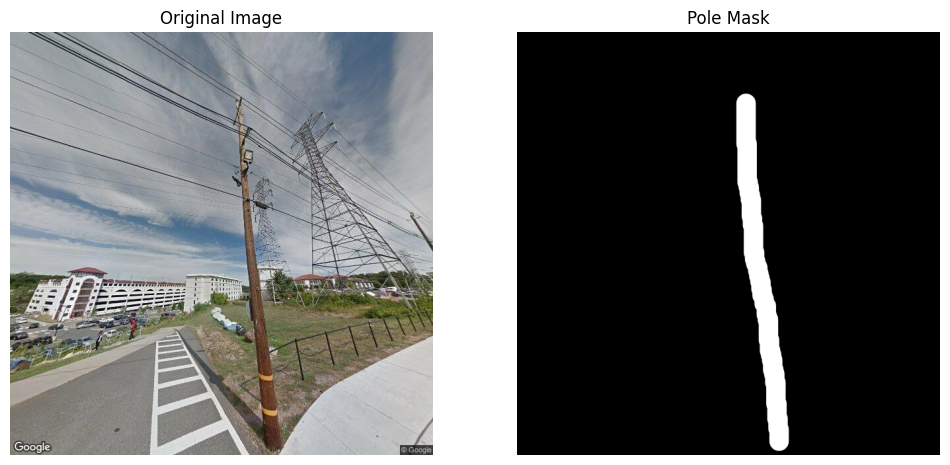

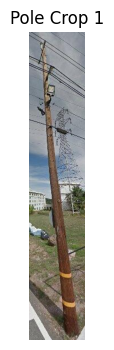

Extracted 1 pole crops

=== STAGE 2: Material Classification ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]



--- Analyzing Pole 1 ---
DL Classification: metal (confidence: 0.52)
Texture Analysis - Std: 42.86, Entropy: 7.40, Laplacian Var: 8553.34
Texture Analysis: metal (confidence: 0.80)


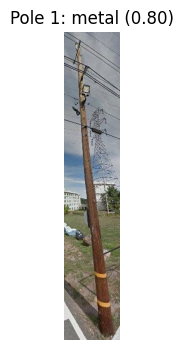


=== FINAL RESULTS ===
Pole 1: metal (confidence: 0.80)


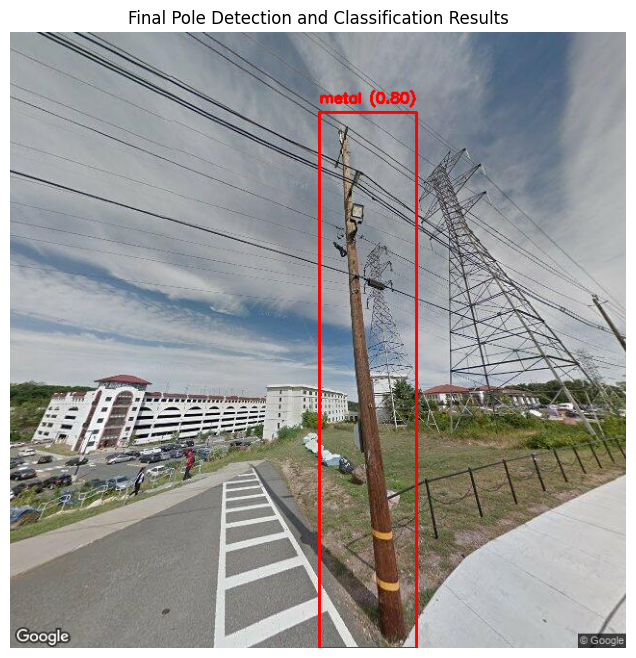

In [ ]:
def main():
    # File paths
    image_path = "/content/image.png"
    mask_path = "/content/task-759-annotation-811-by-1-tag-Pole-0.png"

    print("=== STAGE 1: Pole Detection ===")
    # Load and process mask
    image, mask = load_and_process_mask(image_path, mask_path)

    # Extract pole crops
    pole_crops, bounding_boxes = extract_pole_crops(image, mask)

    if not pole_crops:
        print("No poles detected!")
        return

    print("\n=== STAGE 2: Material Classification ===")
    # Prepare classifier
    model, transform = prepare_classifier()

    # Analyze each pole
    results = []
    for i, pole_crop in enumerate(pole_crops):
        print(f"\n--- Analyzing Pole {i+1} ---")

        # Method 1: Deep Learning Classification
        material, confidence = classify_pole_material(pole_crop, model, transform)
        print(f"DL Classification: {material} (confidence: {confidence:.2f})")

        # Method 2: Texture Analysis (as fallback)
        texture_material, texture_confidence = analyze_pole_texture(pole_crop)
        print(f"Texture Analysis: {texture_material} (confidence: {texture_confidence:.2f})")

        # Combine results (simple heuristic)
        final_material = material if confidence > 0.6 else texture_material
        final_confidence = max(confidence, texture_confidence)

        results.append({
            'pole_id': i+1,
            'bbox': bounding_boxes[i],
            'material': final_material,
            'confidence': final_confidence,
            'dl_prediction': material,
            'texture_prediction': texture_material
        })

        # Display result
        plt.figure(figsize=(4, 4))
        plt.imshow(pole_crop)
        plt.title(f'Pole {i+1}: {final_material} ({final_confidence:.2f})')
        plt.axis('off')
        plt.show()

    print("\n=== FINAL RESULTS ===")
    for result in results:
        print(f"Pole {result['pole_id']}: {result['material']} "
              f"(confidence: {result['confidence']:.2f})")

    # Create final visualization
    display_final_results(image, results)

def display_final_results(image, results):
    """
    Display the original image with bounding boxes and labels
    """
    result_image = image.copy()

    for result in results:
        x1, y1, x2, y2 = result['bbox']
        material = result['material']
        confidence = result['confidence']

        # Choose color based on material
        color = (255, 0, 0) if material == 'metal' else (0, 255, 0)  # Red for metal, Green for wood

        # Draw bounding box
        cv2.rectangle(result_image, (x1, y1), (x2, y2), color, 2)

        # Draw label
        label = f"{material} ({confidence:.2f})"
        cv2.putText(result_image, label, (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(result_image)
    plt.title('Final Pole Detection and Classification Results')
    plt.axis('off')
    plt.show()

# Run the main pipeline
if __name__ == "__main__":
    main()

Using device: cuda
=== POLE DETECTION AND CLASSIFICATION PIPELINE ===

=== STAGE 1: POLE DETECTION ===
Image shape: (640, 640, 3)
Mask shape: (640, 640)


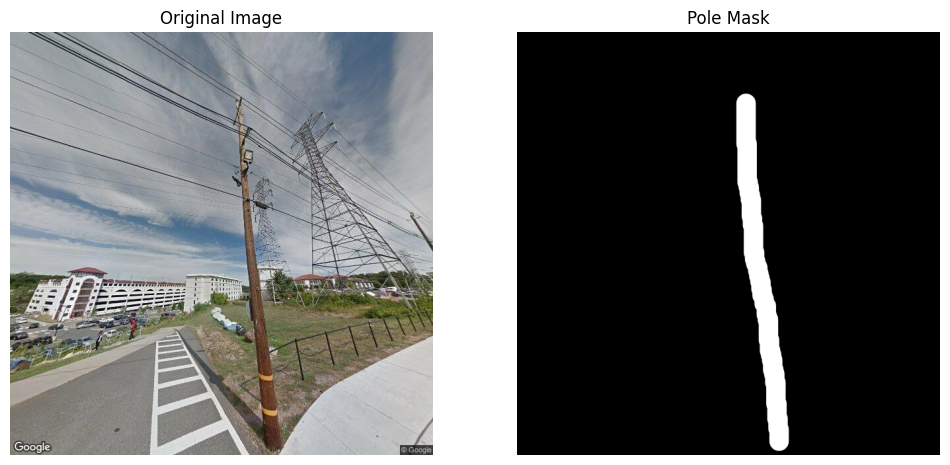

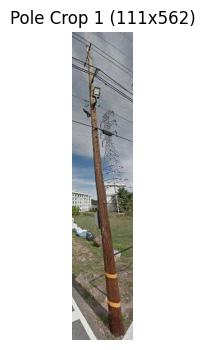

Extracted 1 pole crops

=== STAGE 2: MATERIAL CLASSIFICATION ===

ANALYZING POLE 1

--- PREDICTION RESULTS ---
Deep Learning:          metal  (confidence: 0.739)
Feature-based:          metal  (confidence: 0.556)
Texture Analysis:       metal  (confidence: 0.850)
Metal Score:            5.00
Wood Score:             4.00
FINAL DECISION:         metal  (confidence: 1.000)

--- KEY FEATURE VALUES ---
Edge Density        :  8215.12
Texture Variation   :    42.53
Entropy             :     7.40
Edge Ratio          :     0.99
Saturation          :    52.12
Color Variation     :    45.06


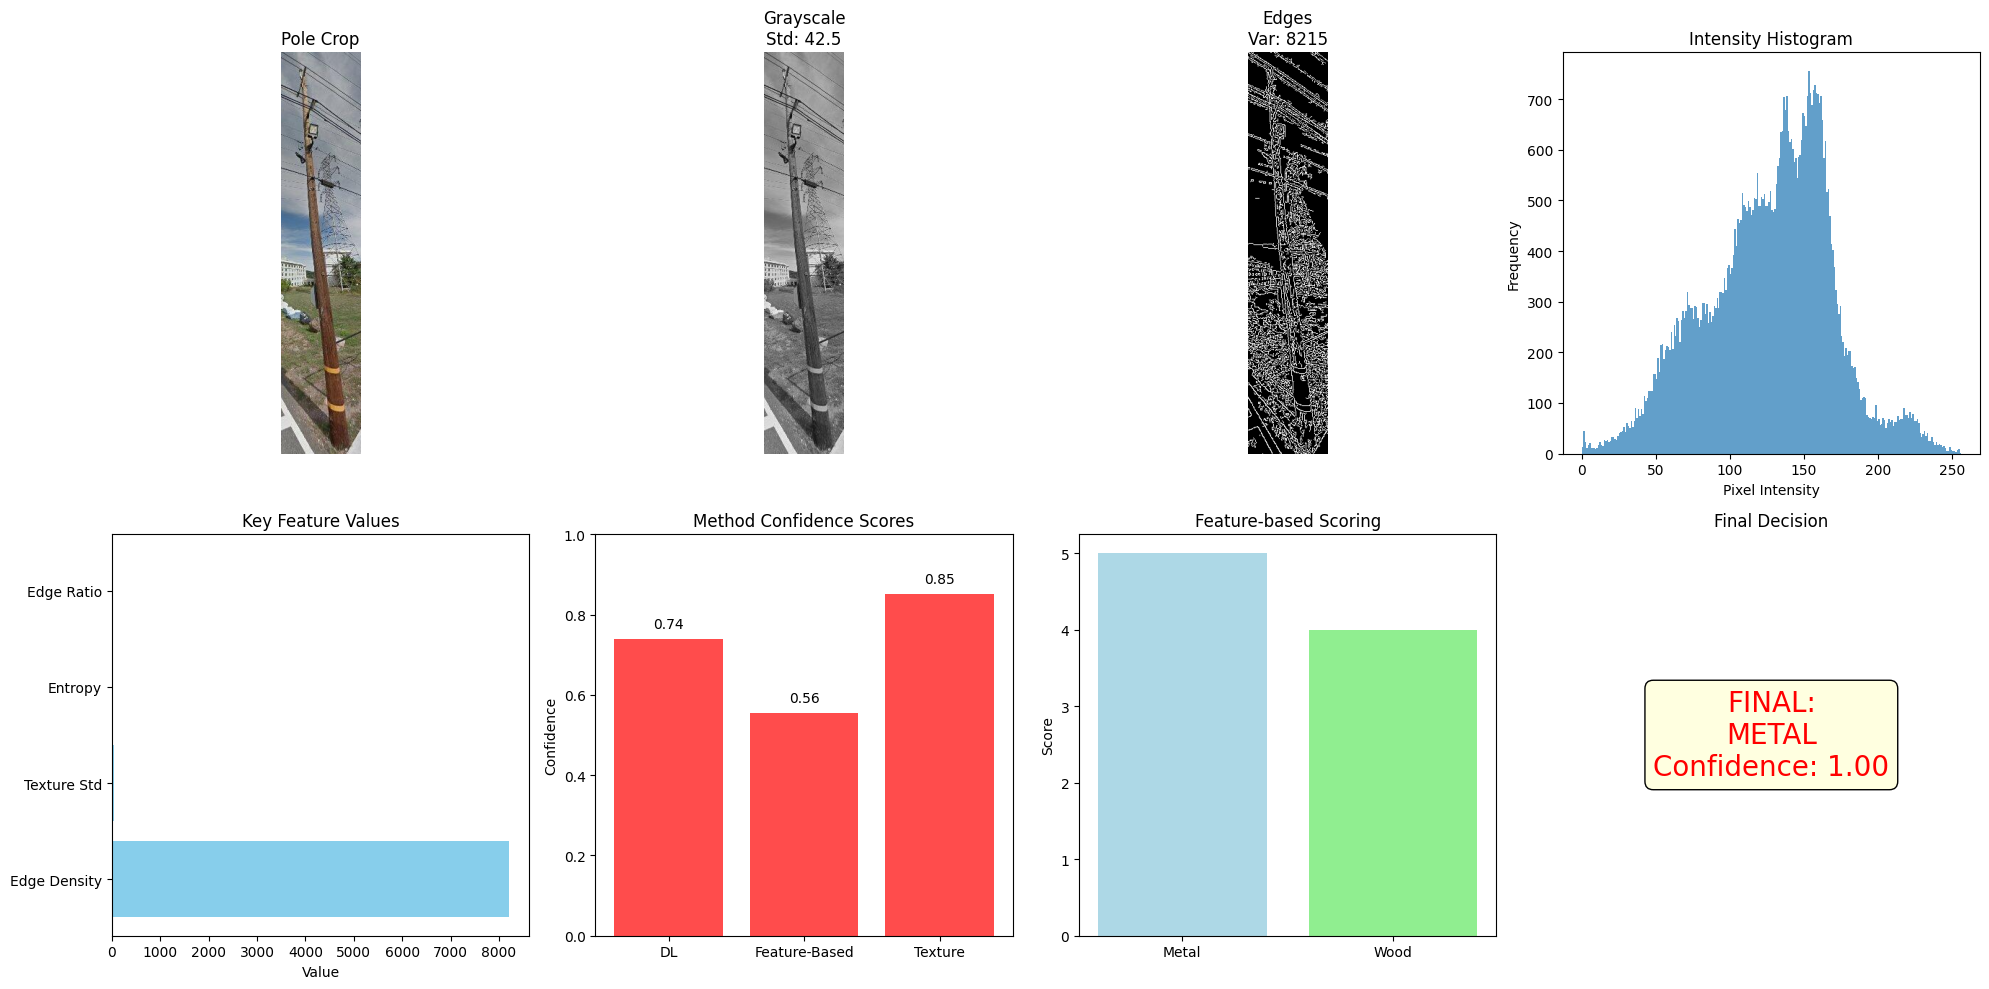


=== FINAL SUMMARY ===
Pole 1: metal (confidence: 1.000)


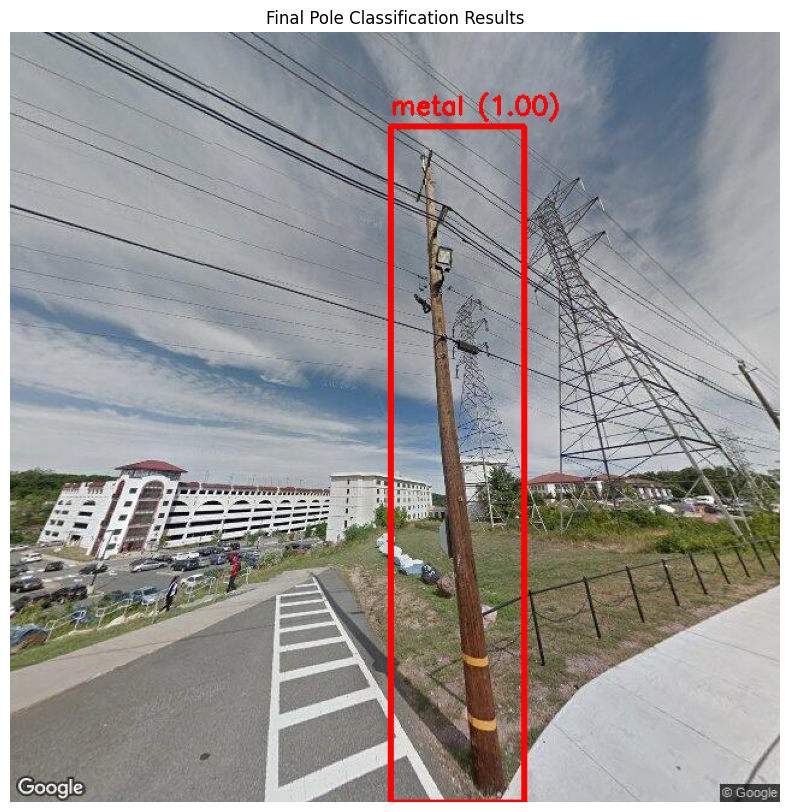

Detailed results saved to detailed_pole_results.txt

=== PIPELINE COMPLETED SUCCESSFULLY ===


In [ ]:
import cv2
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models
import torch.nn.functional as F
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class ImprovedPoleClassifier:
    """
    Comprehensive pole classification system with multiple methods
    """

    def __init__(self):
        self.device = device
        self.setup_transforms()
        self.setup_models()

    def setup_transforms(self):
        """Setup image transformations for DL model"""
        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

    def setup_models(self):
        """Initialize all classification models"""
        self.dl_model = self.create_dl_classifier()
        self.feature_classifier = None  # Would be trained on real data

    def create_dl_classifier(self):
        """Create DL-based material classifier"""
        model = models.resnet18(pretrained=True)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 2)  # 2 classes: metal, wood
        )
        model = model.to(self.device)
        model.eval()
        return model

def load_and_process_mask(image_path, mask_path):
    """
    Stage 1: Load image and mask, then extract pole crops
    """
    # Load image and mask
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not load image from {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise ValueError(f"Could not load mask from {mask_path}")

    print(f"Image shape: {image.shape}")
    print(f"Mask shape: {mask.shape}")

    # Display original image and mask
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Pole Mask')
    axes[1].axis('off')
    plt.show()

    return image, mask

def extract_pole_crops(image, mask, min_area=100):
    """
    Extract individual pole crops from the image using the mask
    """
    # Find contours in the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    pole_crops = []
    bounding_boxes = []

    for i, contour in enumerate(contours):
        # Filter by area
        area = cv2.contourArea(contour)
        if area < min_area:
            continue

        # Get bounding box for each contour
        x, y, w, h = cv2.boundingRect(contour)

        # Add some padding around the detection
        padding = 15
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(image.shape[1], x + w + padding)
        y2 = min(image.shape[0], y + h + padding)

        # Ensure reasonable aspect ratio (poles are typically tall and thin)
        crop_height = y2 - y1
        crop_width = x2 - x1

        if crop_height > crop_width * 1.5:  # Basic aspect ratio check
            # Extract the crop
            pole_crop = image[y1:y2, x1:x2]

            if pole_crop.size > 0 and pole_crop.shape[0] > 10 and pole_crop.shape[1] > 10:
                pole_crops.append(pole_crop)
                bounding_boxes.append((x1, y1, x2, y2))

                # Display each detected pole
                plt.figure(figsize=(4, 4))
                plt.imshow(pole_crop)
                plt.title(f'Pole Crop {i+1} ({crop_width}x{crop_height})')
                plt.axis('off')
                plt.show()

    print(f"Extracted {len(pole_crops)} pole crops")
    return pole_crops, bounding_boxes

def comprehensive_feature_analysis(pole_crop):
    """
    Comprehensive feature analysis for metal vs wood classification
    """
    if len(pole_crop.shape) == 3:
        gray = cv2.cvtColor(pole_crop, cv2.COLOR_RGB2GRAY)
        hsv = cv2.cvtColor(pole_crop, cv2.COLOR_RGB2HSV)
        lab = cv2.cvtColor(pole_crop, cv2.COLOR_RGB2LAB)
    else:
        gray = pole_crop
        hsv = np.zeros_like(pole_crop)
        lab = np.zeros_like(pole_crop)

    features = {}

    # 1. TEXTURE FEATURES
    features['texture_std'] = np.std(gray)

    # Entropy
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist = hist / hist.sum()
    features['entropy'] = -np.sum(hist * np.log2(hist + 1e-10))

    # Laplacian variance (edge density)
    features['laplacian_var'] = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Gabor filter responses
    def apply_gabor_filter(image, theta=0):
        gabor_kernel = cv2.getGaborKernel((21, 21), 5.0, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F)
        filtered = cv2.filter2D(image, cv2.CV_8UC3, gabor_kernel)
        return np.mean(filtered)

    features['gabor_0'] = apply_gabor_filter(gray, 0)
    features['gabor_45'] = apply_gabor_filter(gray, np.pi/4)
    features['gabor_90'] = apply_gabor_filter(gray, np.pi/2)

    # 2. COLOR FEATURES
    if len(pole_crop.shape) == 3:
        # Color variance in different spaces
        features['color_std_rgb'] = np.std(pole_crop, axis=(0,1)).mean()
        features['color_std_hsv'] = np.std(hsv, axis=(0,1)).mean()
        features['color_std_lab'] = np.std(lab, axis=(0,1)).mean()

        # Saturation and Value (HSV space)
        features['saturation_mean'] = np.mean(hsv[:,:,1])
        features['value_mean'] = np.mean(hsv[:,:,2])
        features['lightness_mean'] = np.mean(lab[:,:,0])

        # Color ratios (useful for rust vs wood tones)
        r, g, b = cv2.split(pole_crop)
        features['r_g_ratio'] = np.mean(r) / (np.mean(g) + 1e-10)
        features['r_b_ratio'] = np.mean(r) / (np.mean(b) + 1e-10)
    else:
        features.update({
            'color_std_rgb': 0, 'color_std_hsv': 0, 'color_std_lab': 0,
            'saturation_mean': 0, 'value_mean': 0, 'lightness_mean': 0,
            'r_g_ratio': 0, 'r_b_ratio': 0
        })

    # 3. STRUCTURAL FEATURES
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
    features['edge_density_horizontal'] = np.mean(np.abs(sobelx))
    features['edge_density_vertical'] = np.mean(np.abs(sobely))
    features['edge_ratio'] = features['edge_density_vertical'] / (features['edge_density_horizontal'] + 1e-10)

    return features

def improved_feature_based_classification(features):
    """
    Enhanced feature-based classification with better weighting
    """
    metal_score = 0
    wood_score = 0

    # METAL CHARACTERISTICS (weighted scoring)
    # High edge density is very indicative of metal
    if features['laplacian_var'] > 2000:
        metal_score += 3.0
    elif features['laplacian_var'] > 1000:
        metal_score += 2.0
    elif features['laplacian_var'] > 500:
        metal_score += 1.0

    # Smooth texture favors metal
    if features['texture_std'] < 30:
        metal_score += 2.0
    elif features['texture_std'] < 45:
        metal_score += 1.0

    # Strong vertical structures (metal poles are uniform)
    if features['edge_ratio'] > 1.5:
        metal_score += 1.5

    # Low saturation (grays, metals)
    if features['saturation_mean'] < 60:
        metal_score += 1.0

    # WOOD CHARACTERISTICS
    # High texture variation strongly indicates wood
    if features['texture_std'] > 50:
        wood_score += 3.0
    elif features['texture_std'] > 40:
        wood_score += 2.0
    elif features['texture_std'] > 30:
        wood_score += 1.0

    # High entropy (randomness of wood grain)
    if features['entropy'] > 7.2:
        wood_score += 2.0
    elif features['entropy'] > 6.8:
        wood_score += 1.0

    # Lower edge density (softer edges in wood)
    if features['laplacian_var'] < 300:
        wood_score += 2.0
    elif features['laplacian_var'] < 800:
        wood_score += 1.0

    # Color ratios (wood often has warmer tones)
    if features['r_g_ratio'] > 1.1 or features['r_b_ratio'] > 1.2:
        wood_score += 1.0

    # Calculate final confidence
    total_score = metal_score + wood_score
    if total_score == 0:
        return "uncertain", 0.5, metal_score, wood_score

    metal_confidence = metal_score / total_score
    wood_confidence = wood_score / total_score

    if metal_confidence > wood_confidence:
        return "metal", metal_confidence, metal_score, wood_score
    else:
        return "wood", wood_confidence, metal_score, wood_score

def visualize_pole_analysis(pole_crop, features, predictions):
    """
    Create comprehensive visualization for pole analysis
    """
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    # Original image
    axes[0,0].imshow(pole_crop)
    axes[0,0].set_title('Pole Crop')
    axes[0,0].axis('off')

    # Grayscale with key metrics
    gray = cv2.cvtColor(pole_crop, cv2.COLOR_RGB2GRAY) if len(pole_crop.shape) == 3 else pole_crop
    axes[0,1].imshow(gray, cmap='gray')
    axes[0,1].set_title(f'Grayscale\nStd: {features["texture_std"]:.1f}')
    axes[0,1].axis('off')

    # Edge detection
    edges = cv2.Canny(gray, 50, 150)
    axes[0,2].imshow(edges, cmap='gray')
    axes[0,2].set_title(f'Edges\nVar: {features["laplacian_var"]:.0f}')
    axes[0,2].axis('off')

    # Histogram
    axes[0,3].hist(gray.ravel(), 256, [0,256], alpha=0.7)
    axes[0,3].set_title('Intensity Histogram')
    axes[0,3].set_xlabel('Pixel Intensity')
    axes[0,3].set_ylabel('Frequency')

    # Feature comparison
    key_features = ['laplacian_var', 'texture_std', 'entropy', 'edge_ratio']
    feature_values = [features[k] for k in key_features]
    feature_labels = ['Edge Density', 'Texture Std', 'Entropy', 'Edge Ratio']

    axes[1,0].barh(feature_labels, feature_values, color='skyblue')
    axes[1,0].set_title('Key Feature Values')
    axes[1,0].set_xlabel('Value')

    # Scoring visualization
    methods = ['DL', 'Feature-Based', 'Texture']
    scores = [predictions['dl_confidence'], predictions['feature_confidence'], predictions['texture_confidence']]
    colors = ['red' if pred == 'metal' else 'green' for pred in [predictions['dl'], predictions['feature'], predictions['texture']]]

    bars = axes[1,1].bar(methods, scores, color=colors, alpha=0.7)
    axes[1,1].set_ylim(0, 1)
    axes[1,1].set_title('Method Confidence Scores')
    axes[1,1].set_ylabel('Confidence')

    # Add value labels on bars
    for bar, score in zip(bars, scores):
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                      f'{score:.2f}', ha='center', va='bottom')

    # Metal vs Wood score comparison
    axes[1,2].bar(['Metal', 'Wood'], [predictions['metal_score'], predictions['wood_score']],
                 color=['lightblue', 'lightgreen'])
    axes[1,2].set_title('Feature-based Scoring')
    axes[1,2].set_ylabel('Score')

    # Final decision
    final_color = 'red' if predictions['final'] == 'metal' else 'green'
    axes[1,3].text(0.5, 0.5, f"FINAL:\n{predictions['final'].upper()}\nConfidence: {predictions['final_confidence']:.2f}",
                   ha='center', va='center', fontsize=20, color=final_color,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='lightyellow'))
    axes[1,3].set_title('Final Decision')
    axes[1,3].axis('off')

    plt.tight_layout()
    plt.show()

def analyze_pole_texture(pole_crop):
    """
    Texture-based analysis (original method)
    """
    if len(pole_crop.shape) == 3:
        gray = cv2.cvtColor(pole_crop, cv2.COLOR_RGB2GRAY)
    else:
        gray = pole_crop

    texture_std = np.std(gray)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Improved texture analysis
    if laplacian_var > 2000:
        return "metal", 0.85
    elif laplacian_var > 1000:
        return "metal", 0.75
    elif texture_std > 50:
        return "wood", 0.80
    elif texture_std > 40:
        return "wood", 0.70
    else:
        return "uncertain", 0.5

def classify_pole_material(pole_crop, model, transform):
    """
    DL-based classification
    """
    # Convert to PIL Image
    pil_image = Image.fromarray(pole_crop)

    # Apply transformations
    input_tensor = transform(pil_image).unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probabilities, 1).item()

    class_names = ['metal', 'wood']
    confidence = probabilities[0][predicted_class].item()

    return class_names[predicted_class], confidence

def analyze_single_pole(pole_crop, pole_id, classifier):
    """
    Comprehensive analysis for a single pole
    """
    print(f"\n{'='*50}")
    print(f"ANALYZING POLE {pole_id}")
    print(f"{'='*50}")

    # 1. Extract comprehensive features
    features = comprehensive_feature_analysis(pole_crop)

    # 2. Get predictions from all methods
    # DL Classification
    dl_material, dl_confidence = classify_pole_material(pole_crop, classifier.dl_model, classifier.transform)

    # Feature-based classification
    feature_material, feature_confidence, metal_score, wood_score = improved_feature_based_classification(features)

    # Texture analysis
    texture_material, texture_confidence = analyze_pole_texture(pole_crop)

    # 3. Make final decision
    final_material, final_confidence = make_final_decision(
        dl_material, dl_confidence,
        feature_material, feature_confidence,
        texture_material, texture_confidence,
        metal_score, wood_score
    )

    # 4. Print detailed results
    print(f"\n--- PREDICTION RESULTS ---")
    print(f"Deep Learning:          {dl_material:6} (confidence: {dl_confidence:.3f})")
    print(f"Feature-based:          {feature_material:6} (confidence: {feature_confidence:.3f})")
    print(f"Texture Analysis:       {texture_material:6} (confidence: {texture_confidence:.3f})")
    print(f"Metal Score:            {metal_score:.2f}")
    print(f"Wood Score:             {wood_score:.2f}")
    print(f"FINAL DECISION:         {final_material:6} (confidence: {final_confidence:.3f})")

    print(f"\n--- KEY FEATURE VALUES ---")
    key_feature_map = {
        'laplacian_var': 'Edge Density',
        'texture_std': 'Texture Variation',
        'entropy': 'Entropy',
        'edge_ratio': 'Edge Ratio',
        'saturation_mean': 'Saturation',
        'color_std_rgb': 'Color Variation'
    }

    for feature_key, description in key_feature_map.items():
        print(f"{description:20}: {features[feature_key]:8.2f}")

    # 5. Create visualization
    predictions = {
        'dl': dl_material, 'dl_confidence': dl_confidence,
        'feature': feature_material, 'feature_confidence': feature_confidence,
        'texture': texture_material, 'texture_confidence': texture_confidence,
        'metal_score': metal_score, 'wood_score': wood_score,
        'final': final_material, 'final_confidence': final_confidence
    }

    visualize_pole_analysis(pole_crop, features, predictions)

    return {
        'pole_id': pole_id,
        'final_material': final_material,
        'final_confidence': final_confidence,
        'dl_prediction': dl_material,
        'feature_prediction': feature_material,
        'texture_prediction': texture_material,
        'features': features,
        'scores': {'metal': metal_score, 'wood': wood_score}
    }

def make_final_decision(dl_mat, dl_conf, feat_mat, feat_conf, tex_mat, tex_conf, metal_score, wood_score):
    """
    Make final decision based on all methods with weighting
    """
    # Weight different methods
    dl_weight = 0.4 if dl_conf > 0.6 else 0.2  # Trust DL more when confident
    feature_weight = 0.4
    texture_weight = 0.2

    metal_votes = 0
    wood_votes = 0
    total_confidence = 0

    # Count votes with weights
    if dl_mat == 'metal':
        metal_votes += dl_weight * dl_conf
    else:
        wood_votes += dl_weight * dl_conf

    if feat_mat == 'metal':
        metal_votes += feature_weight * feat_conf
    else:
        wood_votes += feature_weight * feat_conf

    if tex_mat == 'metal':
        metal_votes += texture_weight * tex_conf
    else:
        wood_votes += texture_weight * tex_conf

    # Consider raw scores as tie-breaker
    score_ratio = metal_score / (metal_score + wood_score + 1e-10)
    if metal_score > wood_score * 1.5:
        metal_votes += 0.1
    elif wood_score > metal_score * 1.5:
        wood_votes += 0.1

    total_votes = metal_votes + wood_votes
    if total_votes == 0:
        return "uncertain", 0.5

    if metal_votes > wood_votes:
        confidence = metal_votes / total_votes
        return "metal", confidence
    else:
        confidence = wood_votes / total_votes
        return "wood", confidence

def display_final_results(image, all_results):
    """
    Display final results on original image
    """
    result_image = image.copy()

    for result in all_results:
        bbox = result['bbox']
        material = result['final_material']
        confidence = result['final_confidence']

        # Choose color based on material
        color = (255, 0, 0) if material == 'metal' else (0, 255, 0)  # Red for metal, Green for wood

        # Draw bounding box
        x1, y1, x2, y2 = bbox
        cv2.rectangle(result_image, (x1, y1), (x2, y2), color, 3)

        # Draw label with confidence
        label = f"{material} ({confidence:.2f})"
        cv2.putText(result_image, label, (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Add pole ID
        cv2.putText(result_image, f"Pole {result['pole_id']}", (x1, y2+25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    plt.figure(figsize=(15, 10))
    plt.imshow(result_image)
    plt.title('Final Pole Classification Results')
    plt.axis('off')
    plt.show()

def save_detailed_results(all_results, output_path="detailed_pole_results.txt"):
    """
    Save comprehensive results to file
    """
    with open(output_path, 'w') as f:
        f.write("COMPREHENSIVE POLE CLASSIFICATION RESULTS\n")
        f.write("=" * 50 + "\n\n")

        for result in all_results:
            f.write(f"POLE {result['pole_id']}:\n")
            f.write(f"  Final Decision: {result['final_material']} (confidence: {result['final_confidence']:.3f})\n")
            f.write(f"  DL Prediction: {result['dl_prediction']}\n")
            f.write(f"  Feature Prediction: {result['feature_prediction']}\n")
            f.write(f"  Texture Prediction: {result['texture_prediction']}\n")
            f.write(f"  Metal Score: {result['scores']['metal']:.2f}\n")
            f.write(f"  Wood Score: {result['scores']['wood']:.2f}\n")

            f.write("  Key Features:\n")
            key_features = ['laplacian_var', 'texture_std', 'entropy', 'edge_ratio', 'saturation_mean']
            for feat in key_features:
                f.write(f"    {feat:15}: {result['features'][feat]:8.2f}\n")

            f.write("-" * 30 + "\n")

    print(f"Detailed results saved to {output_path}")

# Main execution function
def main():
    """
    Main pipeline for pole detection and classification
    """
    # File paths
    image_path = "/content/image.png"
    mask_path = "/content/task-759-annotation-811-by-1-tag-Pole-0.png"

    try:
        print("=== POLE DETECTION AND CLASSIFICATION PIPELINE ===")

        # Initialize classifier
        classifier = ImprovedPoleClassifier()

        # Stage 1: Pole Detection
        print("\n=== STAGE 1: POLE DETECTION ===")
        image, mask = load_and_process_mask(image_path, mask_path)
        pole_crops, bounding_boxes = extract_pole_crops(image, mask)

        if not pole_crops:
            print("No poles detected!")
            return

        # Stage 2: Material Classification
        print("\n=== STAGE 2: MATERIAL CLASSIFICATION ===")
        all_results = []

        for i, (pole_crop, bbox) in enumerate(zip(pole_crops, bounding_boxes)):
            result = analyze_single_pole(pole_crop, i+1, classifier)
            result['bbox'] = bbox
            all_results.append(result)

        # Display final results
        print("\n=== FINAL SUMMARY ===")
        for result in all_results:
            print(f"Pole {result['pole_id']}: {result['final_material']} "
                  f"(confidence: {result['final_confidence']:.3f})")

        # Create final visualization
        display_final_results(image, all_results)

        # Save results
        save_detailed_results(all_results)

        print("\n=== PIPELINE COMPLETED SUCCESSFULLY ===")

    except Exception as e:
        print(f"Error in pipeline: {e}")
        import traceback
        traceback.print_exc()

# Run the main pipeline
if __name__ == "__main__":
    main()